# EDA de características radiomics extraídas

Revisión de los CSV radiomics extraídos.

Objetivos:
- localizar los CSV disponibles
- resumir tamaño, pacientes, columnas y tipos de variables
- detectar columnas diagnósticas, metadatos y variables no numéricas
- cuantificar NaN y columnas problemáticas
- previsualizar una limpieza mínima de la matriz de características
- estimar el efecto de estrategias de reducción como `VarianceThreshold` y `PCA`


In [1]:
#importacion librerias
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid', context='notebook')

## 1. Configuración de rutas

- `BATCH_ROOTS` incluye los lotes preprocesados que se quieren rastrear automáticamente.
- `MULTIWINDOWING_BATCH_ROOT` apunta al batch nuevo con `resize_cube128_multiwindowing_separadas` y `resize_cube64_multiwindowing_separadas`.
- `EXTRA_FILES` permite añadir manualmente CSV adicionales, por ejemplo de la grid lung+nodule, si se quieren comparar en el mismo notebook.


In [2]:
BATCH_ROOT = Path('/home/mcribilles/tfm/codigo_nuevo/radiomica_preprocessed_batches/radiomics_preprocessed_allmasks__2026-06-08__19-45-43/results')
MULTIWINDOWING_BATCH_ROOT = Path('/home/mcribilles/tfm/codigo_nuevo/radiomica_preprocessed_batches/radiomics_preprocessed_multiwindowing_only_fixmerge__2026-07-03__14-45-58/results')
GRID_FEATURE_ROOT = Path('/home/mcribilles/tfm/codigo_nuevo/radiomica_grids/multimask_clinical_grid__2026-06-03__09-41-12/features')

BATCH_ROOTS = [
    BATCH_ROOT,
    MULTIWINDOWING_BATCH_ROOT,
]

EXTRA_FILES = [
    # CSV lung+nodule usados como respaldo porque el lote allmasks puede no conservar los *_all_raw.csv.
    GRID_FEATURE_ROOT / 'radiomics__basic__lung__nodule.csv',
    GRID_FEATURE_ROOT / 'radiomics__extended__lung__nodule.csv',
]

RAW_GLOBS = [
    '*/radiomics_preprocessed_*_basic_all_raw.csv',
    '*/radiomics_preprocessed_*_extended_all_raw.csv',
    '*/radiomics_preprocessed_*_basic_all_per_mask.csv',
    '*/radiomics_preprocessed_*_extended_all_per_mask.csv',
]


In [3]:
discovered_files = []
for root in BATCH_ROOTS:
    for pattern in RAW_GLOBS:
        discovered_files.extend(root.glob(pattern))

discovered_files = sorted(set(discovered_files))
candidate_files = discovered_files + [p for p in EXTRA_FILES if p not in discovered_files]

file_records = []
for p in candidate_files:
    exists = p.exists()
    size_bytes = p.stat().st_size if exists else np.nan
    is_nonempty_csv = exists and size_bytes > 1
    file_records.append({
        'label': p.stem,
        'path': str(p),
        'exists': exists,
        'size_bytes': size_bytes,
        'usable': is_nonempty_csv,
    })

files_df = pd.DataFrame(file_records, columns=['label', 'path', 'exists', 'size_bytes', 'usable'])
all_files = [Path(row['path']) for _, row in files_df[files_df['usable']].iterrows()]

print(f'CSV candidatos detectados: {len(candidate_files)}')
print(f'CSV utilizables para el EDA: {len(all_files)}')
display(files_df)

skipped_files_df = files_df[~files_df['usable']]
if not skipped_files_df.empty:
    print('CSV descartados por estar vacios o no existir:')
    display(skipped_files_df)

if files_df.empty:
    print('No se han localizado CSV automáticamente. Revisa BATCH_ROOTS o añade rutas en EXTRA_FILES.')
elif not all_files:
    print('No hay CSV utilizables. Los candidatos encontrados estan vacios o no existen.')


CSV candidatos detectados: 10
CSV utilizables para el EDA: 10


,label,path,exists,size_bytes,usable
0,radiomics_preprocessed_resize_cube128_multiwin...,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,True,9060149,True
1,radiomics_preprocessed_resize_cube128_multiwin...,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,True,7876680,True
2,radiomics_preprocessed_resize_cube128_multiwin...,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,True,99791165,True
3,radiomics_preprocessed_resize_cube128_multiwin...,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,True,85089576,True
4,radiomics_preprocessed_resize_cube64_multiwind...,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,True,8719410,True
5,radiomics_preprocessed_resize_cube64_multiwind...,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,True,7574768,True
6,radiomics_preprocessed_resize_cube64_multiwind...,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,True,95885517,True
7,radiomics_preprocessed_resize_cube64_multiwind...,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,True,81639035,True
8,radiomics__basic__lung__nodule,/home/mcribilles/tfm/codigo_nuevo/radiomica_gr...,True,796742,True
9,radiomics__extended__lung__nodule,/home/mcribilles/tfm/codigo_nuevo/radiomica_gr...,True,10093989,True


## 2. Utilidades de análisis

In [4]:
BASE_META_COLS = ['patient_id', 'preproc_name', 'mask_kind', 'image_path', 'image_size', 'image_spacing']
MAX_FEATURES_FOR_FULL_DATASET_SUMMARY = 5000
SUMMARY_SAMPLE_ROWS = 25


def load_dataset(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)


def split_columns_from_names(columns: list[str]) -> dict:
    meta_cols = [c for c in BASE_META_COLS if c in columns]
    diag_cols = [c for c in columns if 'diagnostics' in c.lower()]
    candidate_feature_cols = [c for c in columns if c not in meta_cols and c not in diag_cols]
    return {
        'meta_cols': meta_cols,
        'diag_cols': diag_cols,
        'candidate_feature_cols': candidate_feature_cols,
    }


def split_columns(df: pd.DataFrame):
    name_parts = split_columns_from_names(df.columns.tolist())
    candidate_feature_cols = name_parts['candidate_feature_cols']
    non_numeric_feature_cols = [c for c in candidate_feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
    numeric_feature_cols = [c for c in candidate_feature_cols if c not in non_numeric_feature_cols]
    return {
        'meta_cols': name_parts['meta_cols'],
        'diag_cols': name_parts['diag_cols'],
        'candidate_feature_cols': candidate_feature_cols,
        'non_numeric_feature_cols': non_numeric_feature_cols,
        'numeric_feature_cols': numeric_feature_cols,
    }


MASK_PREFIXES = ['trachea_bronchia', 'lung', 'nodule', 'vessels', 'trachea', 'bronchia']


def infer_mask_name(col: str) -> str:
    for prefix in MASK_PREFIXES:
        if col.startswith(prefix + '_'):
            return prefix
    return 'unknown'


def strip_mask_prefix(col: str) -> str:
    mask = infer_mask_name(col)
    if mask != 'unknown':
        return col[len(mask) + 1:]
    return col


def infer_image_type_name(col: str) -> str:
    parts = strip_mask_prefix(col).split('_')
    return parts[0] if parts else 'unknown'


def infer_group_name(col: str) -> str:
    parts = strip_mask_prefix(col).split('_')
    if len(parts) >= 2:
        return parts[1]
    return 'unknown'


def dataset_summary(path: Path) -> dict:
    header_cols = pd.read_csv(path, nrows=0).columns.tolist()
    header_parts = split_columns_from_names(header_cols)

    if len(header_parts['candidate_feature_cols']) > MAX_FEATURES_FOR_FULL_DATASET_SUMMARY:
        meta_cols = [c for c in ['patient_id', 'preproc_name'] if c in header_cols]
        meta_df = pd.read_csv(path, usecols=meta_cols) if meta_cols else pd.DataFrame()
        sample_df = pd.read_csv(path, nrows=SUMMARY_SAMPLE_ROWS)
        sample_parts = split_columns(sample_df)
        duplicated_patients = int(meta_df['patient_id'].duplicated().sum()) if 'patient_id' in meta_df.columns else np.nan
        n_unique_patients = int(meta_df['patient_id'].nunique()) if 'patient_id' in meta_df.columns else np.nan
        n_preproc = int(meta_df['preproc_name'].nunique()) if 'preproc_name' in meta_df.columns else np.nan

        return {
            'label': path.stem,
            'rows': int(meta_df.shape[0]) if not meta_df.empty else np.nan,
            'cols_total': len(header_cols),
            'unique_patients': n_unique_patients,
            'duplicated_patient_rows': duplicated_patients,
            'preproc_names': n_preproc,
            'meta_cols': len(header_parts['meta_cols']),
            'diagnostics_cols': len(header_parts['diag_cols']),
            'candidate_feature_cols': len(header_parts['candidate_feature_cols']),
            'numeric_feature_cols': len(sample_parts['numeric_feature_cols']),
            'non_numeric_feature_cols': len(sample_parts['non_numeric_feature_cols']),
            'numeric_nan_cells': np.nan,
            'numeric_cols_with_nan': np.nan,
            'rows_with_any_numeric_nan': np.nan,
            'summary_mode': 'lightweight_header_sample',
        }

    df = load_dataset(path)
    parts = split_columns(df)
    numeric_block = df[parts['numeric_feature_cols']] if parts['numeric_feature_cols'] else pd.DataFrame(index=df.index)
    nan_cells = int(numeric_block.isna().sum().sum()) if not numeric_block.empty else 0
    cols_with_nan = int((numeric_block.isna().sum() > 0).sum()) if not numeric_block.empty else 0
    rows_with_nan = int(numeric_block.isna().any(axis=1).sum()) if not numeric_block.empty else 0
    duplicated_patients = int(df['patient_id'].duplicated().sum()) if 'patient_id' in df.columns else np.nan
    n_unique_patients = int(df['patient_id'].nunique()) if 'patient_id' in df.columns else np.nan
    n_preproc = int(df['preproc_name'].nunique()) if 'preproc_name' in df.columns else np.nan

    return {
        'label': path.stem,
        'rows': int(df.shape[0]),
        'cols_total': int(df.shape[1]),
        'unique_patients': n_unique_patients,
        'duplicated_patient_rows': duplicated_patients,
        'preproc_names': n_preproc,
        'meta_cols': len(parts['meta_cols']),
        'diagnostics_cols': len(parts['diag_cols']),
        'candidate_feature_cols': len(parts['candidate_feature_cols']),
        'numeric_feature_cols': len(parts['numeric_feature_cols']),
        'non_numeric_feature_cols': len(parts['non_numeric_feature_cols']),
        'numeric_nan_cells': nan_cells,
        'numeric_cols_with_nan': cols_with_nan,
        'rows_with_any_numeric_nan': rows_with_nan,
        'summary_mode': 'full',
    }


def prepare_numeric_matrix(df: pd.DataFrame):
    parts = split_columns(df)
    work = df.copy()
    candidate_feature_cols = parts['candidate_feature_cols']
    numeric = work[candidate_feature_cols].apply(pd.to_numeric, errors='coerce') if candidate_feature_cols else pd.DataFrame(index=work.index)
    all_nan_cols = numeric.columns[numeric.isna().all()].tolist() if not numeric.empty else []
    numeric = numeric.drop(columns=all_nan_cols, errors='ignore')
    constant_cols = [c for c in numeric.columns if numeric[c].nunique(dropna=True) <= 1]
    medians = numeric.median(numeric_only=True)
    numeric_imputed = numeric.fillna(medians)
    return {
        'meta_df': work[parts['meta_cols']].copy(),
        'diag_cols': parts['diag_cols'],
        'numeric_raw': numeric,
        'numeric_imputed': numeric_imputed,
        'all_nan_cols': all_nan_cols,
        'constant_cols': constant_cols,
        'non_numeric_feature_cols': parts['non_numeric_feature_cols'],
    }

## 3. Resumen global de los CSV detectados

In [5]:
if all_files:
    summary_df = pd.DataFrame([dataset_summary(p) for p in all_files]).sort_values(['rows', 'cols_total'], ascending=[False, False])
    display(summary_df)
else:
    summary_df = pd.DataFrame()

,label,rows,cols_total,unique_patients,duplicated_patient_rows,preproc_names,meta_cols,diagnostics_cols,candidate_feature_cols,numeric_feature_cols,non_numeric_feature_cols,numeric_nan_cells,numeric_cols_with_nan,rows_with_any_numeric_nan,summary_mode
2,radiomics_preprocessed_resize_cube128_multiwin...,810,24054,205,605,1.0,6,444,23604,23604,0,NaN,NaN,NaN,lightweight_header_sample
0,radiomics_preprocessed_resize_cube128_multiwin...,810,1734,205,605,1.0,6,444,1284,1284,0,780275.0,1284.0,810.0,full
6,radiomics_preprocessed_resize_cube64_multiwind...,792,24054,205,587,1.0,6,444,23604,23604,0,NaN,NaN,NaN,lightweight_header_sample
4,radiomics_preprocessed_resize_cube64_multiwind...,792,1734,205,587,1.0,6,444,1284,1284,0,762696.0,1284.0,792.0,full
9,radiomics__extended__lung__nodule,206,2965,206,0,NaN,4,0,2961,2961,0,10347.0,2961.0,6.0,full
8,radiomics__basic__lung__nodule,206,218,206,0,NaN,4,0,214,214,0,535.0,214.0,5.0,full
3,radiomics_preprocessed_resize_cube128_multiwin...,205,24053,205,0,1.0,5,444,23604,23604,0,NaN,NaN,NaN,lightweight_header_sample
7,radiomics_preprocessed_resize_cube64_multiwind...,205,24053,205,0,1.0,5,444,23604,23604,0,NaN,NaN,NaN,lightweight_header_sample
1,radiomics_preprocessed_resize_cube128_multiwin...,205,1733,205,0,1.0,5,444,1284,1284,0,3455.0,321.0,12.0,full
5,radiomics_preprocessed_resize_cube64_multiwind...,205,1733,205,0,1.0,5,444,1284,1284,0,8988.0,642.0,27.0,full


## 3.1 EDA específico multiwindowing

Resumen de las características extraídas correctamente en `resize_cube128_multiwindowing_separadas` y `resize_cube64_multiwindowing_separadas`, separando `basic`/`extended` y `all_raw`/`all_per_mask`.


,label,config,tipo_extraccion,formato,path,rows,cols_total,unique_patients,duplicated_patient_rows,mask_kind_levels,diagnostics_cols,candidate_feature_cols,numeric_feature_cols_sample,all_nan_cols,constant_cols,features_tras_limpieza_estimadas,numeric_cols_with_nan,numeric_nan_pct,nan_calculado_completo
0,radiomics_preprocessed_resize_cube128_multiwin...,resize_cube128_multiwindowing_separadas,basic,all_per_mask,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,810,1734,205,605,"lung, nodule, trachea_bronchia, vessels",444,1284,1284,NaN,NaN,1284,NaN,NaN,False
1,radiomics_preprocessed_resize_cube128_multiwin...,resize_cube128_multiwindowing_separadas,basic,all_raw,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,205,1733,205,0,wide_all_masks,444,1284,1284,NaN,NaN,1284,NaN,NaN,False
2,radiomics_preprocessed_resize_cube128_multiwin...,resize_cube128_multiwindowing_separadas,extended,all_per_mask,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,810,24054,205,605,"lung, nodule, trachea_bronchia, vessels",444,23604,23604,NaN,NaN,23604,NaN,NaN,False
3,radiomics_preprocessed_resize_cube128_multiwin...,resize_cube128_multiwindowing_separadas,extended,all_raw,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,205,24053,205,0,wide_all_masks,444,23604,23604,NaN,NaN,23604,NaN,NaN,False
4,radiomics_preprocessed_resize_cube64_multiwind...,resize_cube64_multiwindowing_separadas,basic,all_per_mask,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,792,1734,205,587,"lung, nodule, trachea_bronchia, vessels",444,1284,1284,NaN,NaN,1284,NaN,NaN,False
5,radiomics_preprocessed_resize_cube64_multiwind...,resize_cube64_multiwindowing_separadas,basic,all_raw,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,205,1733,205,0,wide_all_masks,444,1284,1284,NaN,NaN,1284,NaN,NaN,False
6,radiomics_preprocessed_resize_cube64_multiwind...,resize_cube64_multiwindowing_separadas,extended,all_per_mask,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,792,24054,205,587,"lung, nodule, trachea_bronchia, vessels",444,23604,23604,NaN,NaN,23604,NaN,NaN,False
7,radiomics_preprocessed_resize_cube64_multiwind...,resize_cube64_multiwindowing_separadas,extended,all_raw,/home/mcribilles/tfm/codigo_nuevo/radiomica_pr...,205,24053,205,0,wide_all_masks,444,23604,23604,NaN,NaN,23604,NaN,NaN,False


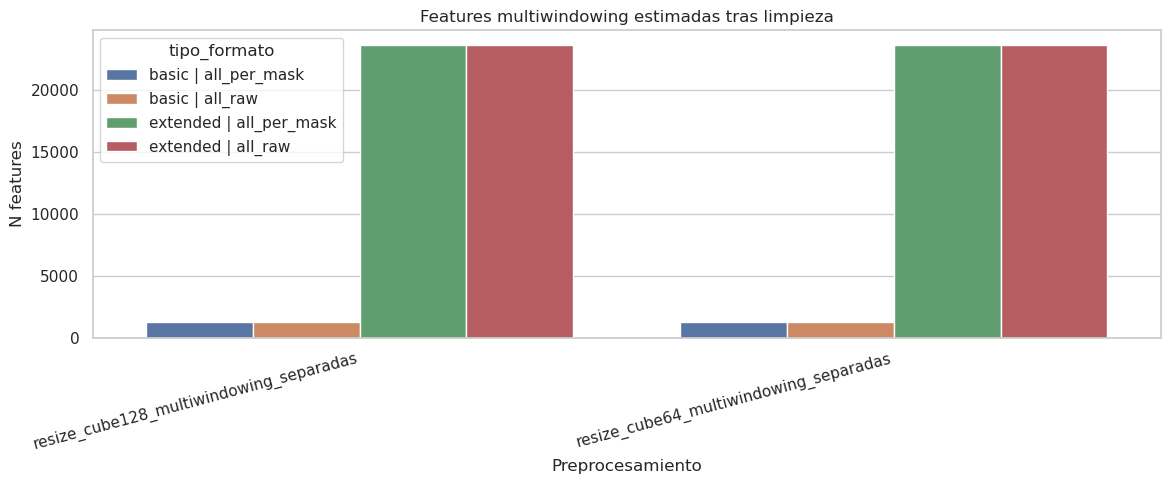

NaN/constantes completos no calculados para multiwindowing; activa CALCULAR_NAN_MULTIWINDOWING_COMPLETO=True si quieres ese chequeo pesado.


,config,tipo_extraccion,formato,mask,channel,family,n_features
0,resize_cube128_multiwindowing_separadas,basic,all_per_mask,lung,ch0,firstorder,18
1,resize_cube128_multiwindowing_separadas,basic,all_per_mask,lung,ch0,glcm,24
2,resize_cube128_multiwindowing_separadas,basic,all_per_mask,lung,ch0,gldm,14
3,resize_cube128_multiwindowing_separadas,basic,all_per_mask,lung,ch0,glrlm,16
4,resize_cube128_multiwindowing_separadas,basic,all_per_mask,lung,ch0,glszm,16
5,resize_cube128_multiwindowing_separadas,basic,all_per_mask,lung,ch0,ngtdm,5
6,resize_cube128_multiwindowing_separadas,basic,all_per_mask,lung,ch0,shape,14
7,resize_cube128_multiwindowing_separadas,basic,all_per_mask,lung,ch1,firstorder,18
8,resize_cube128_multiwindowing_separadas,basic,all_per_mask,lung,ch1,glcm,24
9,resize_cube128_multiwindowing_separadas,basic,all_per_mask,lung,ch1,gldm,14


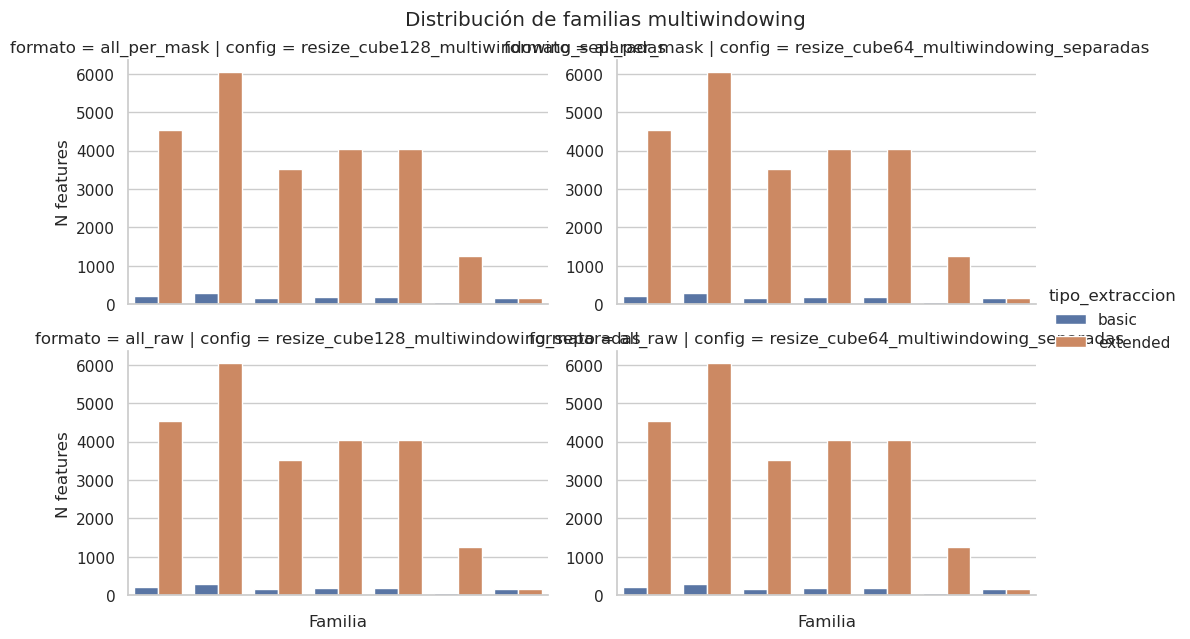

In [6]:
MULTIWINDOWING_TOKEN = 'multiwindowing_separadas'
CALCULAR_NAN_MULTIWINDOWING_COMPLETO = False
MULTIWINDOWING_SAMPLE_ROWS = 25


def is_multiwindowing_file(path: Path) -> bool:
    return MULTIWINDOWING_TOKEN in path.stem or MULTIWINDOWING_TOKEN in path.parent.name


def parse_multiwindowing_file(path: Path) -> dict:
    label = path.stem
    if 'resize_cube128' in label:
        config = 'resize_cube128_multiwindowing_separadas'
    elif 'resize_cube64' in label:
        config = 'resize_cube64_multiwindowing_separadas'
    else:
        config = path.parent.name

    if '_extended_' in label:
        tipo_extraccion = 'extended'
    elif '_basic_' in label:
        tipo_extraccion = 'basic'
    else:
        tipo_extraccion = 'unknown'

    if label.endswith('_all_per_mask'):
        formato = 'all_per_mask'
    elif label.endswith('_all_raw'):
        formato = 'all_raw'
    else:
        formato = 'unknown'

    return {
        'label': label,
        'config': config,
        'tipo_extraccion': tipo_extraccion,
        'formato': formato,
    }


def infer_multiwindowing_channel(col: str) -> str:
    parts = strip_mask_prefix(col).split('_')
    if parts and parts[0].startswith('ch'):
        return parts[0]
    return 'unknown'


def infer_multiwindowing_image_type(col: str) -> str:
    parts = strip_mask_prefix(col).split('_')
    if len(parts) >= 2 and parts[0].startswith('ch'):
        return parts[1]
    return infer_image_type_name(col)


def infer_multiwindowing_family(col: str) -> str:
    parts = strip_mask_prefix(col).split('_')
    if len(parts) >= 3 and parts[0].startswith('ch'):
        return parts[2]
    return infer_group_name(col)


def split_columns_from_names(columns: list[str]) -> dict:
    meta_cols = [c for c in BASE_META_COLS if c in columns]
    diag_cols = [c for c in columns if 'diagnostics' in c.lower()]
    candidate_feature_cols = [c for c in columns if c not in meta_cols and c not in diag_cols]
    return {
        'meta_cols': meta_cols,
        'diag_cols': diag_cols,
        'candidate_feature_cols': candidate_feature_cols,
    }


def multiwindowing_feature_taxonomy(feature_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in feature_cols:
        rows.append({
            'feature': col,
            'mask': infer_mask_name(col),
            'channel': infer_multiwindowing_channel(col),
            'image_type': infer_multiwindowing_image_type(col),
            'family': infer_multiwindowing_family(col),
        })
    return pd.DataFrame(rows)


def lightweight_multiwindowing_summary(path: Path) -> tuple[dict, pd.DataFrame]:
    header_cols = pd.read_csv(path, nrows=0).columns.tolist()
    parts_header = split_columns_from_names(header_cols)
    meta_cols = [c for c in ['patient_id', 'preproc_name', 'mask_kind'] if c in header_cols]
    meta_df = pd.read_csv(path, usecols=meta_cols) if meta_cols else pd.DataFrame()
    sample_df = pd.read_csv(path, nrows=MULTIWINDOWING_SAMPLE_ROWS)
    parts_sample = split_columns(sample_df)

    parsed = parse_multiwindowing_file(path)
    parsed.update({
        'path': str(path),
        'rows': int(meta_df.shape[0]) if not meta_df.empty else int(pd.read_csv(path, usecols=[header_cols[0]]).shape[0]),
        'cols_total': len(header_cols),
        'unique_patients': int(meta_df['patient_id'].nunique()) if 'patient_id' in meta_df.columns else np.nan,
        'duplicated_patient_rows': int(meta_df['patient_id'].duplicated().sum()) if 'patient_id' in meta_df.columns else np.nan,
        'mask_kind_levels': ', '.join(sorted(meta_df['mask_kind'].dropna().astype(str).unique())) if 'mask_kind' in meta_df.columns else 'wide_all_masks',
        'diagnostics_cols': len(parts_header['diag_cols']),
        'candidate_feature_cols': len(parts_header['candidate_feature_cols']),
        'numeric_feature_cols_sample': len(parts_sample['numeric_feature_cols']),
        'all_nan_cols': np.nan,
        'constant_cols': np.nan,
        'features_tras_limpieza_estimadas': len(parts_header['candidate_feature_cols']),
        'numeric_cols_with_nan': np.nan,
        'numeric_nan_pct': np.nan,
        'nan_calculado_completo': False,
    })

    if CALCULAR_NAN_MULTIWINDOWING_COMPLETO:
        df_full = load_dataset(path)
        prep_full = prepare_numeric_matrix(df_full)
        numeric_raw = prep_full['numeric_raw']
        numeric_cells = numeric_raw.shape[0] * numeric_raw.shape[1]
        numeric_nan_cells = int(numeric_raw.isna().sum().sum()) if numeric_cells else 0
        parsed.update({
            'numeric_feature_cols_sample': numeric_raw.shape[1] + len(prep_full['all_nan_cols']),
            'all_nan_cols': len(prep_full['all_nan_cols']),
            'constant_cols': len(prep_full['constant_cols']),
            'features_tras_limpieza_estimadas': prep_full['numeric_imputed'].shape[1],
            'numeric_cols_with_nan': int((numeric_raw.isna().sum() > 0).sum()) if not numeric_raw.empty else 0,
            'numeric_nan_pct': round(100 * numeric_nan_cells / numeric_cells, 3) if numeric_cells else 0.0,
            'nan_calculado_completo': True,
        })

    taxonomy = multiwindowing_feature_taxonomy(parts_header['candidate_feature_cols'])
    return parsed, taxonomy


multiwindowing_files = [p for p in all_files if is_multiwindowing_file(p)] if 'all_files' in globals() else []

multiwindowing_summary_rows = []
multiwindowing_family_rows = []
for path in multiwindowing_files:
    parsed, taxonomy_mw = lightweight_multiwindowing_summary(path)
    multiwindowing_summary_rows.append(parsed)

    if not taxonomy_mw.empty:
        family_counts = (
            taxonomy_mw
            .groupby(['mask', 'channel', 'image_type', 'family'])
            .size()
            .reset_index(name='n_features')
        )
        for key, value in parse_multiwindowing_file(path).items():
            family_counts[key] = value
        multiwindowing_family_rows.append(family_counts)

if multiwindowing_summary_rows:
    multiwindowing_summary_df = pd.DataFrame(multiwindowing_summary_rows).sort_values(['config', 'tipo_extraccion', 'formato'])
    display(multiwindowing_summary_df)

    plot_df = multiwindowing_summary_df.copy()
    plot_df['tipo_formato'] = plot_df['tipo_extraccion'] + ' | ' + plot_df['formato']
    plt.figure(figsize=(12, 5))
    sns.barplot(data=plot_df, x='config', y='features_tras_limpieza_estimadas', hue='tipo_formato')
    plt.title('Features multiwindowing estimadas tras limpieza')
    plt.xlabel('Preprocesamiento')
    plt.ylabel('N features')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()

    if CALCULAR_NAN_MULTIWINDOWING_COMPLETO:
        plt.figure(figsize=(12, 4))
        sns.barplot(data=plot_df, x='config', y='numeric_nan_pct', hue='tipo_formato')
        plt.title('Porcentaje de NaN en bloque numérico multiwindowing')
        plt.xlabel('Preprocesamiento')
        plt.ylabel('% NaN')
        plt.xticks(rotation=15, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print('NaN/constantes completos no calculados para multiwindowing; activa CALCULAR_NAN_MULTIWINDOWING_COMPLETO=True si quieres ese chequeo pesado.')

    if multiwindowing_family_rows:
        multiwindowing_family_df = pd.concat(multiwindowing_family_rows, ignore_index=True)
        family_summary = (
            multiwindowing_family_df
            .groupby(['config', 'tipo_extraccion', 'formato', 'mask', 'channel', 'family'], as_index=False)['n_features']
            .sum()
            .sort_values(['config', 'tipo_extraccion', 'formato', 'mask', 'channel', 'family'])
        )
        display(family_summary.head(120))

        family_plot = (
            family_summary
            .groupby(['config', 'tipo_extraccion', 'formato', 'family'], as_index=False)['n_features']
            .sum()
        )
        g = sns.catplot(
            data=family_plot,
            x='family',
            y='n_features',
            hue='tipo_extraccion',
            col='config',
            row='formato',
            kind='bar',
            height=3.2,
            aspect=1.6,
            sharey=False,
        )
        g.set_xticklabels(rotation=45, ha='right')
        g.set_axis_labels('Familia', 'N features')
        g.fig.suptitle('Distribución de familias multiwindowing', y=1.02)
        plt.show()
else:
    multiwindowing_summary_df = pd.DataFrame()
    multiwindowing_family_df = pd.DataFrame()
    print('No se han encontrado CSV multiwindowing utilizables en all_files.')

## 4. Selección del dataset para análisis detallado

Si hay varios CSV, se escoge por defecto el primero existente. Puedes cambiar `SELECTED_LABEL` manualmente.


In [7]:
existing_files = [p for p in all_files if p.exists()]
if not existing_files:
    raise FileNotFoundError('No hay CSV accesibles con la configuración actual.')

DEFAULT_LABEL = existing_files[0].stem
SELECTED_LABEL = DEFAULT_LABEL

selected_path = next(p for p in existing_files if p.stem == SELECTED_LABEL)
print('Dataset seleccionado:', selected_path)

df = load_dataset(selected_path)
parts = split_columns(df)
prep = prepare_numeric_matrix(df)

Dataset seleccionado: /home/mcribilles/tfm/codigo_nuevo/radiomica_preprocessed_batches/radiomics_preprocessed_multiwindowing_only_fixmerge__2026-07-03__14-45-58/results/resize_cube128_multiwindowing_separadas/radiomics_preprocessed_resize_cube128_multiwindowing_separadas_basic_all_per_mask.csv


In [8]:
print('Shape:', df.shape)
print('\nPrimeras filas:')
display(df.head())

print('\nColumnas de metadatos:', parts['meta_cols'])
print('\nNumero de columnas diagnostics:', len(parts['diag_cols']))
print('Numero de columnas de caracteristicas candidatas:', len(parts['candidate_feature_cols']))
print('Numero de columnas de caracteristicas no numericas:', len(parts['non_numeric_feature_cols']))

if parts['non_numeric_feature_cols']:
    display(pd.DataFrame({'non_numeric_feature_cols': parts['non_numeric_feature_cols'][:50]}))

Shape: (810, 1734)

Primeras filas:


,patient_id,preproc_name,mask_kind,image_path,image_size,image_spacing,lung_ch0_diagnostics_Versions_PyRadiomics,lung_ch0_diagnostics_Versions_Numpy,lung_ch0_diagnostics_Versions_SimpleITK,lung_ch0_diagnostics_Versions_PyWavelet,lung_ch0_diagnostics_Versions_Python,lung_ch0_diagnostics_Configuration_Settings,lung_ch0_diagnostics_Configuration_EnabledImageTypes,lung_ch0_diagnostics_Image-original_Hash,lung_ch0_diagnostics_Image-original_Dimensionality,lung_ch0_diagnostics_Image-original_Spacing,lung_ch0_diagnostics_Image-original_Size,lung_ch0_diagnostics_Image-original_Mean,lung_ch0_diagnostics_Image-original_Minimum,lung_ch0_diagnostics_Image-original_Maximum,lung_ch0_diagnostics_Mask-original_Hash,lung_ch0_diagnostics_Mask-original_Spacing,lung_ch0_diagnostics_Mask-original_Size,lung_ch0_diagnostics_Mask-original_BoundingBox,lung_ch0_diagnostics_Mask-original_VoxelNum,lung_ch0_diagnostics_Mask-original_VolumeNum,lung_ch0_diagnostics_Mask-original_CenterOfMassIndex,lung_ch0_diagnostics_Mask-original_CenterOfMass,lung_ch0_diagnostics_Image-interpolated_Spacing,lung_ch0_diagnostics_Image-interpolated_Size,lung_ch0_diagnostics_Image-interpolated_Mean,lung_ch0_diagnostics_Image-interpolated_Minimum,lung_ch0_diagnostics_Image-interpolated_Maximum,lung_ch0_diagnostics_Mask-interpolated_Spacing,lung_ch0_diagnostics_Mask-interpolated_Size,lung_ch0_diagnostics_Mask-interpolated_BoundingBox,lung_ch0_diagnostics_Mask-interpolated_VoxelNum,lung_ch0_diagnostics_Mask-interpolated_VolumeNum,lung_ch0_diagnostics_Mask-interpolated_CenterOfMassIndex,lung_ch0_diagnostics_Mask-interpolated_CenterOfMass,lung_ch0_diagnostics_Mask-interpolated_Mean,lung_ch0_diagnostics_Mask-interpolated_Minimum,lung_ch0_diagnostics_Mask-interpolated_Maximum,lung_ch0_original_shape_Elongation,lung_ch0_original_shape_Flatness,lung_ch0_original_shape_LeastAxisLength,lung_ch0_original_shape_MajorAxisLength,lung_ch0_original_shape_Maximum2DDiameterColumn,lung_ch0_original_shape_Maximum2DDiameterRow,lung_ch0_original_shape_Maximum2DDiameterSlice,lung_ch0_original_shape_Maximum3DDiameter,lung_ch0_original_shape_MeshVolume,lung_ch0_original_shape_MinorAxisLength,lung_ch0_original_shape_Sphericity,lung_ch0_original_shape_SurfaceArea,lung_ch0_original_shape_SurfaceVolumeRatio,lung_ch0_original_shape_VoxelVolume,lung_ch0_original_firstorder_10Percentile,lung_ch0_original_firstorder_90Percentile,lung_ch0_original_firstorder_Energy,lung_ch0_original_firstorder_Entropy,lung_ch0_original_firstorder_InterquartileRange,lung_ch0_original_firstorder_Kurtosis,lung_ch0_original_firstorder_Maximum,lung_ch0_original_firstorder_MeanAbsoluteDeviation,lung_ch0_original_firstorder_Mean,lung_ch0_original_firstorder_Median,lung_ch0_original_firstorder_Minimum,lung_ch0_original_firstorder_Range,lung_ch0_original_firstorder_RobustMeanAbsoluteDeviation,lung_ch0_original_firstorder_RootMeanSquared,lung_ch0_original_firstorder_Skewness,lung_ch0_original_firstorder_TotalEnergy,lung_ch0_original_firstorder_Uniformity,lung_ch0_original_firstorder_Variance,lung_ch0_original_glcm_Autocorrelation,lung_ch0_original_glcm_ClusterProminence,lung_ch0_original_glcm_ClusterShade,lung_ch0_original_glcm_ClusterTendency,lung_ch0_original_glcm_Contrast,lung_ch0_original_glcm_Correlation,lung_ch0_original_glcm_DifferenceAverage,lung_ch0_original_glcm_DifferenceEntropy,lung_ch0_original_glcm_DifferenceVariance,lung_ch0_original_glcm_Id,lung_ch0_original_glcm_Idm,lung_ch0_original_glcm_Idmn,lung_ch0_original_glcm_Idn,lung_ch0_original_glcm_Imc1,lung_ch0_original_glcm_Imc2,lung_ch0_original_glcm_InverseVariance,lung_ch0_original_glcm_JointAverage,lung_ch0_original_glcm_JointEnergy,lung_ch0_original_glcm_JointEntropy,lung_ch0_original_glcm_MCC,lung_ch0_original_glcm_MaximumProbability,lung_ch0_original_glcm_SumAverage,lung_ch0_original_glcm_SumEntropy,lung_ch0_original_glcm_SumSquares,lung_ch0_original_gldm_DependenceEntropy,...,trachea_bronchia_ch2_original_shape_Maximum3DDiameter,trachea_bronchia_ch2_original_shape_Me


Columnas de metadatos: ['patient_id', 'preproc_name', 'mask_kind', 'image_path', 'image_size', 'image_spacing']

Numero de columnas diagnostics: 444
Numero de columnas de caracteristicas candidatas: 1284
Numero de columnas de caracteristicas no numericas: 0


## 5. Distribución de familias de características

Dataset usado para distribución de familias: /home/mcribilles/tfm/codigo_nuevo/radiomica_grids/multimask_clinical_grid__2026-06-03__09-41-12/features/radiomics__basic__lung__nodule.csv


,n_columnas
family,
glcm,48
firstorder,36
glrlm,32
glszm,32
gldm,28
shape,28
ngtdm,10


family,firstorder,glcm,gldm,glrlm,glszm,ngtdm,shape
mask,,,,,,,
lung,18,24,14,16,16,5,14
nodule,18,24,14,16,16,5,14


,n_columnas
image_type,
original,214


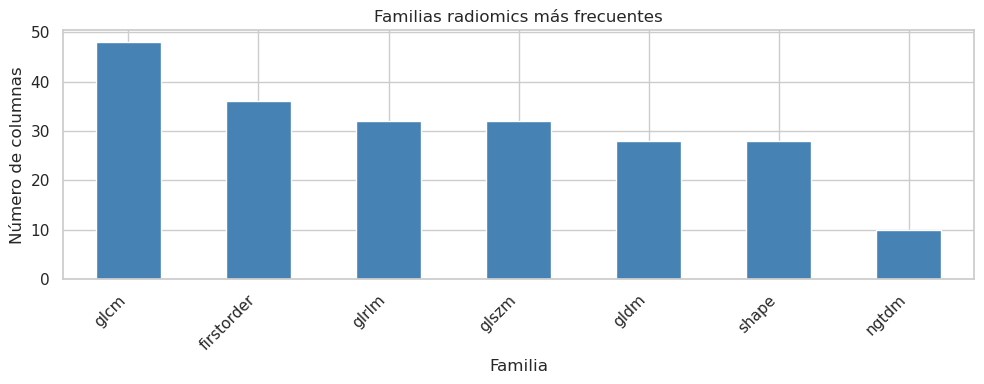

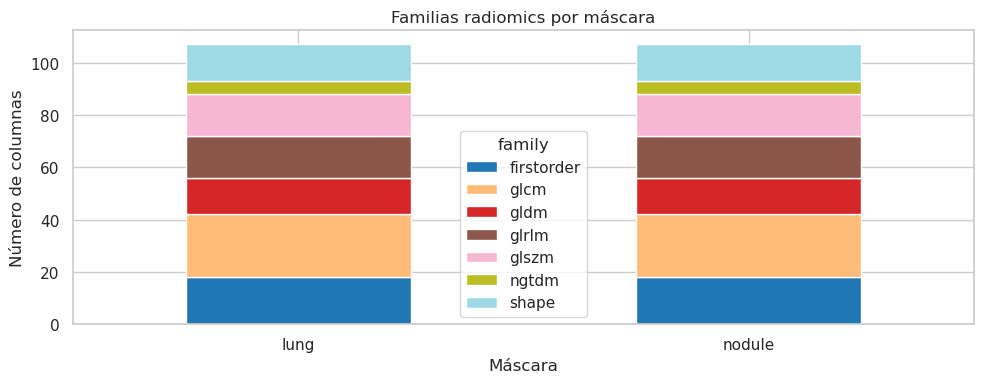

In [9]:
GRID_FEATURE_ROOT = Path('/home/mcribilles/tfm/codigo_nuevo/radiomica_grids/multimask_clinical_grid__2026-06-03__09-41-12/features')
BASIC_LUNG_NODULE_PATH = GRID_FEATURE_ROOT / 'radiomics__basic__lung__nodule.csv'

family_source_path = BASIC_LUNG_NODULE_PATH if BASIC_LUNG_NODULE_PATH.exists() else selected_path
family_df_raw = load_dataset(family_source_path)
family_parts = split_columns(family_df_raw)

feature_taxonomy_df = pd.DataFrame({
    'feature': family_parts['candidate_feature_cols'],
})
feature_taxonomy_df['mask'] = feature_taxonomy_df['feature'].map(infer_mask_name)
feature_taxonomy_df['image_type'] = feature_taxonomy_df['feature'].map(infer_image_type_name)
feature_taxonomy_df['family'] = feature_taxonomy_df['feature'].map(infer_group_name)

print('Dataset usado para distribución de familias:', family_source_path)

family_counts = feature_taxonomy_df['family'].value_counts()
display(family_counts.to_frame('n_columnas'))

mask_family_counts = pd.crosstab(feature_taxonomy_df['mask'], feature_taxonomy_df['family'])
display(mask_family_counts)

image_type_counts = feature_taxonomy_df['image_type'].value_counts().to_frame('n_columnas')
display(image_type_counts)

plt.figure(figsize=(10, 4))
ax = family_counts.head(15).plot(kind='bar', color='steelblue')
ax.set_title('Familias radiomics más frecuentes')
ax.set_xlabel('Familia')
ax.set_ylabel('Número de columnas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

mask_family_counts.plot(kind='bar', stacked=True, figsize=(10, 4), colormap='tab20')
plt.title('Familias radiomics por máscara')
plt.xlabel('Máscara')
plt.ylabel('Número de columnas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Calidad del dato: duplicados, NaN y columnas problemáticas

In [10]:
quality_summary = {
    'rows': len(df),
    'unique_patients': int(df['patient_id'].nunique()) if 'patient_id' in df.columns else np.nan,
    'duplicated_patient_rows': int(df['patient_id'].duplicated().sum()) if 'patient_id' in df.columns else np.nan,
    'diagnostics_cols': len(parts['diag_cols']),
    'non_numeric_feature_cols': len(parts['non_numeric_feature_cols']),
    'all_nan_feature_cols_after_coercion': len(prep['all_nan_cols']),
    'constant_feature_cols_after_coercion': len(prep['constant_cols']),
    'numeric_feature_cols_after_coercion': prep['numeric_raw'].shape[1],
    'rows_with_any_nan_in_numeric_block': int(prep['numeric_raw'].isna().any(axis=1).sum()) if not prep['numeric_raw'].empty else 0,
    'cols_with_any_nan_in_numeric_block': int((prep['numeric_raw'].isna().sum() > 0).sum()) if not prep['numeric_raw'].empty else 0,
}

display(pd.Series(quality_summary).to_frame('value'))

if prep['all_nan_cols']:
    print('\nPrimeras columnas completamente NaN tras coercion numerica:')
    display(pd.DataFrame({'all_nan_cols': prep['all_nan_cols'][:50]}))

if prep['constant_cols']:
    print('\nPrimeras columnas constantes tras coercion:')
    display(pd.DataFrame({'constant_cols': prep['constant_cols'][:50]}))

,value
rows,810
unique_patients,205
duplicated_patient_rows,605
diagnostics_cols,444
non_numeric_feature_cols,0
all_nan_feature_cols_after_coercion,0
constant_feature_cols_after_coercion,0
numeric_feature_cols_after_coercion,1284
rows_with_any_nan_in_numeric_block,810
cols_with_any_nan_in_numeric_block,1284


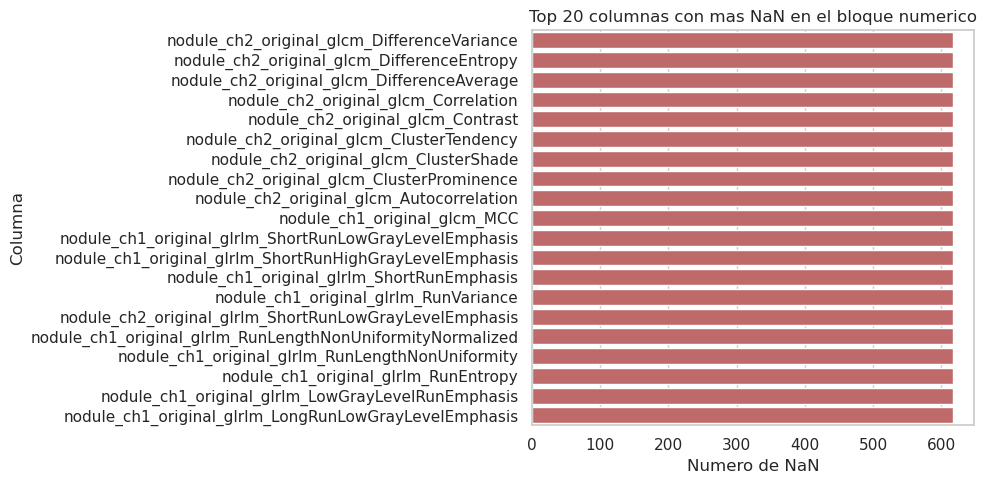

In [11]:
if not prep['numeric_raw'].empty:
    top_missing = prep['numeric_raw'].isna().sum().sort_values(ascending=False)
    top_missing = top_missing[top_missing > 0].head(20)
    if not top_missing.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(x=top_missing.values, y=top_missing.index, color='indianred')
        plt.title('Top 20 columnas con mas NaN en el bloque numerico')
        plt.xlabel('Numero de NaN')
        plt.ylabel('Columna')
        plt.tight_layout()
        plt.show()
    else:
        print('No hay NaN en el bloque numerico.')

## 7. Previsualización del preprocesamiento de la matriz de características

Esta celda reproduce una limpieza mínima orientada a clasificación:
- separación de metadatos;
- eliminación de columnas `diagnostics`;
- coerción numérica con `errors='coerce'`;
- descarte de columnas completamente vacías;
- imputación por mediana en el bloque numérico.


In [ ]:
meta_df = prep['meta_df'].reset_index(drop=True)
X_numeric = prep['numeric_imputed'].copy()

print('Metadatos conservados:', list(meta_df.columns))
print('Shape bloque numerico imputado:', X_numeric.shape)
print('NaN residuales tras imputacion:', int(X_numeric.isna().sum().sum()))

df_ready = pd.concat([meta_df, X_numeric.reset_index(drop=True)], axis=1)
display(df_ready.head())

Metadatos conservados: ['patient_id', 'preproc_name', 'mask_kind', 'image_path', 'image_size', 'image_spacing']
Shape bloque numerico imputado: (810, 1284)
NaN residuales tras imputacion: 0


,patient_id,preproc_name,mask_kind,image_path,image_size,image_spacing,lung_ch0_original_shape_Elongation,lung_ch0_original_shape_Flatness,lung_ch0_original_shape_LeastAxisLength,lung_ch0_original_shape_MajorAxisLength,lung_ch0_original_shape_Maximum2DDiameterColumn,lung_ch0_original_shape_Maximum2DDiameterRow,lung_ch0_original_shape_Maximum2DDiameterSlice,lung_ch0_original_shape_Maximum3DDiameter,lung_ch0_original_shape_MeshVolume,lung_ch0_original_shape_MinorAxisLength,lung_ch0_original_shape_Sphericity,lung_ch0_original_shape_SurfaceArea,lung_ch0_original_shape_SurfaceVolumeRatio,lung_ch0_original_shape_VoxelVolume,lung_ch0_original_firstorder_10Percentile,lung_ch0_original_firstorder_90Percentile,lung_ch0_original_firstorder_Energy,lung_ch0_original_firstorder_Entropy,lung_ch0_original_firstorder_InterquartileRange,lung_ch0_original_firstorder_Kurtosis,lung_ch0_original_firstorder_Maximum,lung_ch0_original_firstorder_MeanAbsoluteDeviation,lung_ch0_original_firstorder_Mean,lung_ch0_original_firstorder_Median,lung_ch0_original_firstorder_Minimum,lung_ch0_original_firstorder_Range,lung_ch0_original_firstorder_RobustMeanAbsoluteDeviation,lung_ch0_original_firstorder_RootMeanSquared,lung_ch0_original_firstorder_Skewness,lung_ch0_original_firstorder_TotalEnergy,lung_ch0_original_firstorder_Uniformity,lung_ch0_original_firstorder_Variance,lung_ch0_original_glcm_Autocorrelation,lung_ch0_original_glcm_ClusterProminence,lung_ch0_original_glcm_ClusterShade,lung_ch0_original_glcm_ClusterTendency,lung_ch0_original_glcm_Contrast,lung_ch0_original_glcm_Correlation,lung_ch0_original_glcm_DifferenceAverage,lung_ch0_original_glcm_DifferenceEntropy,lung_ch0_original_glcm_DifferenceVariance,lung_ch0_original_glcm_Id,lung_ch0_original_glcm_Idm,lung_ch0_original_glcm_Idmn,lung_ch0_original_glcm_Idn,lung_ch0_original_glcm_Imc1,lung_ch0_original_glcm_Imc2,lung_ch0_original_glcm_InverseVariance,lung_ch0_original_glcm_JointAverage,lung_ch0_original_glcm_JointEnergy,lung_ch0_original_glcm_JointEntropy,lung_ch0_original_glcm_MCC,lung_ch0_original_glcm_MaximumProbability,lung_ch0_original_glcm_SumAverage,lung_ch0_original_glcm_SumEntropy,lung_ch0_original_glcm_SumSquares,lung_ch0_original_gldm_DependenceEntropy,lung_ch0_original_gldm_DependenceNonUniformity,lung_ch0_original_gldm_DependenceNonUniformityNormalized,lung_ch0_original_gldm_DependenceVariance,lung_ch0_original_gldm_GrayLevelNonUniformity,lung_ch0_original_gldm_GrayLevelVariance,lung_ch0_original_gldm_HighGrayLevelEmphasis,lung_ch0_original_gldm_LargeDependenceEmphasis,lung_ch0_original_gldm_LargeDependenceHighGrayLevelEmphasis,lung_ch0_original_gldm_LargeDependenceLowGrayLevelEmphasis,lung_ch0_original_gldm_LowGrayLevelEmphasis,lung_ch0_original_gldm_SmallDependenceEmphasis,lung_ch0_original_gldm_SmallDependenceHighGrayLevelEmphasis,lung_ch0_original_gldm_SmallDependenceLowGrayLevelEmphasis,lung_ch0_original_glrlm_GrayLevelNonUniformity,lung_ch0_original_glrlm_GrayLevelNonUniformityNormalized,lung_ch0_original_glrlm_GrayLevelVariance,lung_ch0_original_glrlm_HighGrayLevelRunEmphasis,lung_ch0_original_glrlm_LongRunEmphasis,lung_ch0_original_glrlm_LongRunHighGrayLevelEmphasis,lung_ch0_original_glrlm_LongRunLowGrayLevelEmphasis,lung_ch0_original_glrlm_LowGrayLevelRunEmphasis,lung_ch0_original_glrlm_RunEntropy,lung_ch0_original_glrlm_RunLengthNonUniformity,lung_ch0_original_glrlm_RunLengthNonUniformityNormalized,lung_ch0_original_glrlm_RunPercentage,lung_ch0_original_glrlm_RunVariance,lung_ch0_original_glrlm_ShortRunEmphasis,lung_ch0_original_glrlm_ShortRunHighGrayLevelEmphasis,lung_ch0_original_glrlm_ShortRunLowGrayLevelEmphasis,lung_ch0_original_glszm_GrayLevelNonUniformity,lung_ch0_original_glszm_GrayLevelNonUniformityNormalized,lung_ch0_original_glszm_GrayLevelVariance,lung_ch0_original_glszm_HighGrayLevelZoneEmphasis,lung_ch0_original_glszm_LargeAreaEmphasis,lung_ch0_original_glszm_LargeAreaHighGrayLevelEmphasis,lung_ch0_original_glszm_LargeAreaLowGrayLevelEmphasis,lung_ch0_original_glszm_

## 8. Estimación de reducción de dimensionalidad

In [ ]:
REDUNDANCY_CORR_THRESHOLD = 0.95
REDUNDANCY_METHOD_LABEL = f"sin_redundantes_corr_{REDUNDANCY_CORR_THRESHOLD}"
MAX_FEATURES_FOR_FULL_CORR = 5000
MAX_FEATURES_FOR_DIMRED_CACHE = 5000
MAX_FEATURES_FOR_FULL_PREPARE = 5000



def get_redundant_corr_cols(X: pd.DataFrame, threshold: float = REDUNDANCY_CORR_THRESHOLD) -> list[str]:
    if X.shape[1] < 2:
        return []
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    return [col for col in upper.columns if (upper[col] >= threshold).any()]



def get_redundant_corr_count(X: pd.DataFrame, threshold: float = REDUNDANCY_CORR_THRESHOLD) -> tuple[float, float]:
    if X.shape[1] < 2:
        return 0, X.shape[1]
    if X.shape[1] > MAX_FEATURES_FOR_FULL_CORR:
        return np.nan, np.nan
    redundant_cols = get_redundant_corr_cols(X, threshold=threshold)
    return len(redundant_cols), X.shape[1] - len(redundant_cols)


def nullable_int_min(series: pd.Series):
    values = series.dropna()
    return np.nan if values.empty else int(values.min())


def nullable_int_max(series: pd.Series):
    values = series.dropna()
    return np.nan if values.empty else int(values.max())


def infer_extraction_type_from_label(label: str) -> str:
    if '_extended_' in label:
        return 'extended'
    if '_basic_' in label:
        return 'basic'
    return 'unknown'


redundant_corr_cols = []
nonredundant_feature_count = np.nan
if 'X_numeric' in globals() and not X_numeric.empty:
    redundant_corr_cols = get_redundant_corr_cols(X_numeric)
    nonredundant_feature_count = X_numeric.shape[1] - len(redundant_corr_cols)
    print(f'Dataset seleccionado: {SELECTED_LABEL}')
    print(f'Caracteristicas tras limpieza en dataset seleccionado: {X_numeric.shape[1]}')
    print(f'Caracteristicas redundantes por correlacion >= {REDUNDANCY_CORR_THRESHOLD} en dataset seleccionado: {len(redundant_corr_cols)}')
else:
    print('Ejecuta primero la seccion 7 para construir X_numeric.')

feature_count_summary = pd.DataFrame()
prepared_feature_counts_df = pd.DataFrame()
prepared_feature_matrices = {}
if 'all_files' in globals() and all_files:
    prepared_feature_records = []
    for path in all_files:
        tmp_sample_df = pd.read_csv(path, nrows=25)
        tmp_parts = split_columns(tmp_sample_df)
        raw_candidate_count = len(tmp_parts['candidate_feature_cols'])
        raw_numeric_count = len(tmp_parts['numeric_feature_cols'])

        if raw_candidate_count > MAX_FEATURES_FOR_FULL_PREPARE:
            tmp_feature_count = raw_candidate_count
            tmp_redundant_count = np.nan
            tmp_nonredundant_count = np.nan
        else:
            tmp_df = load_dataset(path)
            tmp_prep = prepare_numeric_matrix(tmp_df)
            tmp_X = tmp_prep['numeric_imputed']
            tmp_feature_count = tmp_X.shape[1]
            if tmp_X.shape[1] <= MAX_FEATURES_FOR_DIMRED_CACHE:
                prepared_feature_matrices[path.stem] = tmp_X
            tmp_redundant_count, tmp_nonredundant_count = get_redundant_corr_count(tmp_X)

        prepared_feature_records.append({
            'label': path.stem,
            'path': str(path),
            'tipo_extraccion': infer_extraction_type_from_label(path.stem),
            'raw_candidate_feature_cols': raw_candidate_count,
            'raw_numeric_feature_cols': raw_numeric_count,
            'features_tras_limpieza': tmp_feature_count,
            'redundant_corr_cols': tmp_redundant_count,
            'features_sin_redundantes': tmp_nonredundant_count,
        })

    prepared_feature_counts_df = pd.DataFrame(prepared_feature_records)
    feature_count_rows = []
    for tipo_extraccion, group in prepared_feature_counts_df.groupby('tipo_extraccion'):
        corr_group = group.dropna(subset=['features_sin_redundantes'])
        feature_count_rows.extend([
            {
                'tipo_extraccion': tipo_extraccion,
                'metodo': 'raw_csv',
                'n_csv': len(group),
                'n_csv_corr_calculada': np.nan,
                'n_features_min': int(group['raw_candidate_feature_cols'].min()),
                'n_features_max': int(group['raw_candidate_feature_cols'].max()),
                'n_redundantes_min': np.nan,
                'n_redundantes_max': np.nan,
            },
            {
                'tipo_extraccion': tipo_extraccion,
                'metodo': 'tras_limpieza',
                'n_csv': len(group),
                'n_csv_corr_calculada': np.nan,
                'n_features_min': int(group['features_tras_limpieza'].min()),
                'n_features_max': int(group['features_tras_limpieza'].max()),
                'n_redundantes_min': np.nan,
                'n_redundantes_max': np.nan,
            },
            {
                'tipo_extraccion': tipo_extraccion,
                'metodo': REDUNDANCY_METHOD_LABEL,
                'n_csv': len(group),
                'n_csv_corr_calculada': len(corr_group),
                'n_features_min': nullable_int_min(group['features_sin_redundantes']),
                'n_features_max': nullable_int_max(group['features_sin_redundantes']),
                'n_redundantes_min': nullable_int_min(group['redundant_corr_cols']),
                'n_redundantes_max': nullable_int_max(group['redundant_corr_cols']),
            },
        ])
    feature_count_summary = pd.DataFrame(feature_count_rows).sort_values(['tipo_extraccion', 'metodo'])
    display(feature_count_summary)

    skipped_corr = int(prepared_feature_counts_df['features_sin_redundantes'].isna().sum())
    if skipped_corr:
        print(f'Redundancia por correlacion no calculada en {skipped_corr} CSV con mas de {MAX_FEATURES_FOR_FULL_CORR} features.')

    extended_counts = feature_count_summary[feature_count_summary['tipo_extraccion'] == 'extended']
    if not extended_counts.empty:
        extended_clean_counts = extended_counts[extended_counts['metodo'] == 'tras_limpieza']
        ext_min = int(extended_clean_counts['n_features_min'].iloc[0])
        ext_max = int(extended_clean_counts['n_features_max'].iloc[0])
        if ext_min == ext_max:
            print(f'Caracteristicas extendidas tras limpieza por CSV: {ext_min}')
        else:
            print(f'Caracteristicas extendidas tras limpieza por CSV: entre {ext_min} y {ext_max}')
    else:
        print('No hay CSV extended utilizables en all_files.')
else:
    print('Ejecuta primero la seccion 1 para construir all_files.')

try:
    from sklearn.decomposition import PCA
    from sklearn.feature_selection import VarianceThreshold
    from sklearn.preprocessing import StandardScaler

    def estimate_dimred_rows(dataset_label: str, tipo_extraccion: str, X: pd.DataFrame) -> list[dict]:
        if X.shape[1] < 2:
            return [{
                'dataset': dataset_label,
                'tipo_extraccion': tipo_extraccion,
                'metodo': 'tras_limpieza',
                'n_features': X.shape[1],
            }]

        vt = VarianceThreshold(threshold=0.01)
        vt.fit(X)
        selected_vt = int(vt.get_support().sum())

        redundant_count, n_nonredundant = get_redundant_corr_count(X)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        pca_90 = PCA(n_components=0.90, svd_solver='full').fit(X_scaled)
        pca_95 = PCA(n_components=0.95, svd_solver='full').fit(X_scaled)
        pca_99 = PCA(n_components=0.99, svd_solver='full').fit(X_scaled)

        return [
            {'dataset': dataset_label, 'tipo_extraccion': tipo_extraccion, 'metodo': 'tras_limpieza', 'n_features': X.shape[1]},
            {'dataset': dataset_label, 'tipo_extraccion': tipo_extraccion, 'metodo': 'VarianceThreshold_0.01', 'n_features': selected_vt},
            {'dataset': dataset_label, 'tipo_extraccion': tipo_extraccion, 'metodo': REDUNDANCY_METHOD_LABEL, 'n_features': n_nonredundant},
            {'dataset': dataset_label, 'tipo_extraccion': tipo_extraccion, 'metodo': 'PCA_90', 'n_features': pca_90.n_components_},
            {'dataset': dataset_label, 'tipo_extraccion': tipo_extraccion, 'metodo': 'PCA_95', 'n_features': pca_95.n_components_},
            {'dataset': dataset_label, 'tipo_extraccion': tipo_extraccion, 'metodo': 'PCA_99', 'n_features': pca_99.n_components_},
        ]

    dimred_rows = []
    if not prepared_feature_counts_df.empty:
        representative_df = (
            prepared_feature_counts_df[prepared_feature_counts_df['tipo_extraccion'].isin(['basic', 'extended'])]
            .sort_values(['tipo_extraccion', 'label'])
            .drop_duplicates('tipo_extraccion')
        )
        for _, representative_row in representative_df.iterrows():
            dataset_label = representative_row['label']
            tipo_extraccion = representative_row['tipo_extraccion']
            X_rep = prepared_feature_matrices.get(dataset_label)
            if X_rep is None:
                print(f'Se omite PCA/redundancia completa para {dataset_label}: demasiadas features para cache/dimred ({representative_row["features_tras_limpieza"]}).')
                continue
            dimred_rows.extend(estimate_dimred_rows(dataset_label, tipo_extraccion, X_rep))
    elif 'X_numeric' in globals() and not X_numeric.empty:
        selected_extraction_type = infer_extraction_type_from_label(SELECTED_LABEL) if 'SELECTED_LABEL' in globals() else 'unknown'
        dimred_rows.extend(estimate_dimred_rows(SELECTED_LABEL, selected_extraction_type, X_numeric))

    if dimred_rows:
        dimred_summary = pd.DataFrame(dimred_rows)
        display(dimred_summary)
    else:
        print('No hay suficientes caracteristicas numericas para estimar reduccion de dimensionalidad.')
except Exception as e:
    print('No se ha podido ejecutar la estimacion de reduccion:', repr(e))

Dataset seleccionado: radiomics_preprocessed_resize_cube128_multiwindowing_separadas_basic_all_per_mask
Caracteristicas tras limpieza en dataset seleccionado: 1284
Caracteristicas redundantes por correlacion >= 0.95 en dataset seleccionado: 841


,tipo_extraccion,metodo,n_csv,n_csv_corr_calculada,n_features_min,n_features_max,n_redundantes_min,n_redundantes_max
0,basic,raw_csv,5,NaN,214,1284,NaN,NaN
2,basic,sin_redundantes_corr_0.95,5,5.0,115,499,99.0,854.0
1,basic,tras_limpieza,5,NaN,214,1284,NaN,NaN
3,extended,raw_csv,5,NaN,2961,23604,NaN,NaN
5,extended,sin_redundantes_corr_0.95,5,1.0,1325,1325,1636.0,1636.0
4,extended,tras_limpieza,5,NaN,2961,23604,NaN,NaN


Redundancia por correlacion no calculada en 4 CSV con mas de 5000 features.
Caracteristicas extendidas tras limpieza por CSV: entre 2961 y 23604


,dataset,tipo_extraccion,metodo,n_features
0,radiomics__basic__lung__nodule,basic,tras_limpieza,214
1,radiomics__basic__lung__nodule,basic,VarianceThreshold_0.01,158
2,radiomics__basic__lung__nodule,basic,sin_redundantes_corr_0.95,115
3,radiomics__basic__lung__nodule,basic,PCA_90,17
4,radiomics__basic__lung__nodule,basic,PCA_95,26
5,radiomics__basic__lung__nodule,basic,PCA_99,48
6,radiomics__extended__lung__nodule,extended,tras_limpieza,2961
7,radiomics__extended__lung__nodule,extended,VarianceThreshold_0.01,1312
8,radiomics__extended__lung__nodule,extended,sin_redundantes_corr_0.95,1325
9,radiomics__extended__lung__nodule,extended,PCA_90,32


## 9. Distribuciones, correlaciones y asociación con complicación

Exploración visual sobre características radiomics originales (`basic`) y extendidas (`extended`), priorizando máscaras de pulmón y nódulo.

- histogramas de características de forma, primer orden y segundo orden;
- mapas de correlación de características originales antes y después de eliminar redundantes;
- distribución de correlaciones absolutas por pares;
- top 20 de características más correlacionadas en valor absoluto con cada etiqueta multietiqueta de complicación para originales y extendidas.


Dataset original/basic usado: radiomics__basic__lung__nodule.csv
Dataset extended usado: radiomics__extended__lung__nodule.csv
Mascaras en features originales/basic: {'lung': 107, 'nodule': 107}
Mascaras en features extendidas: {'lung': 1486, 'nodule': 1475}
Pacientes con etiquetas clinicas: 210
Etiquetas multietiqueta: ['Derrame_pleural', 'Hemorragia', 'Neumotórax', 'Sin_complicación']
Features originales/basic tras limpieza: 214
Features extendidas tras limpieza: 2961


,n_positivos
Derrame_pleural,1
Hemorragia,49
Neumotórax,64
Sin_complicación,105


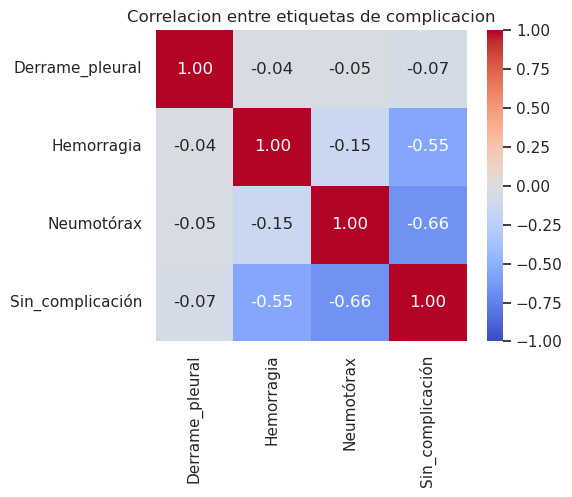

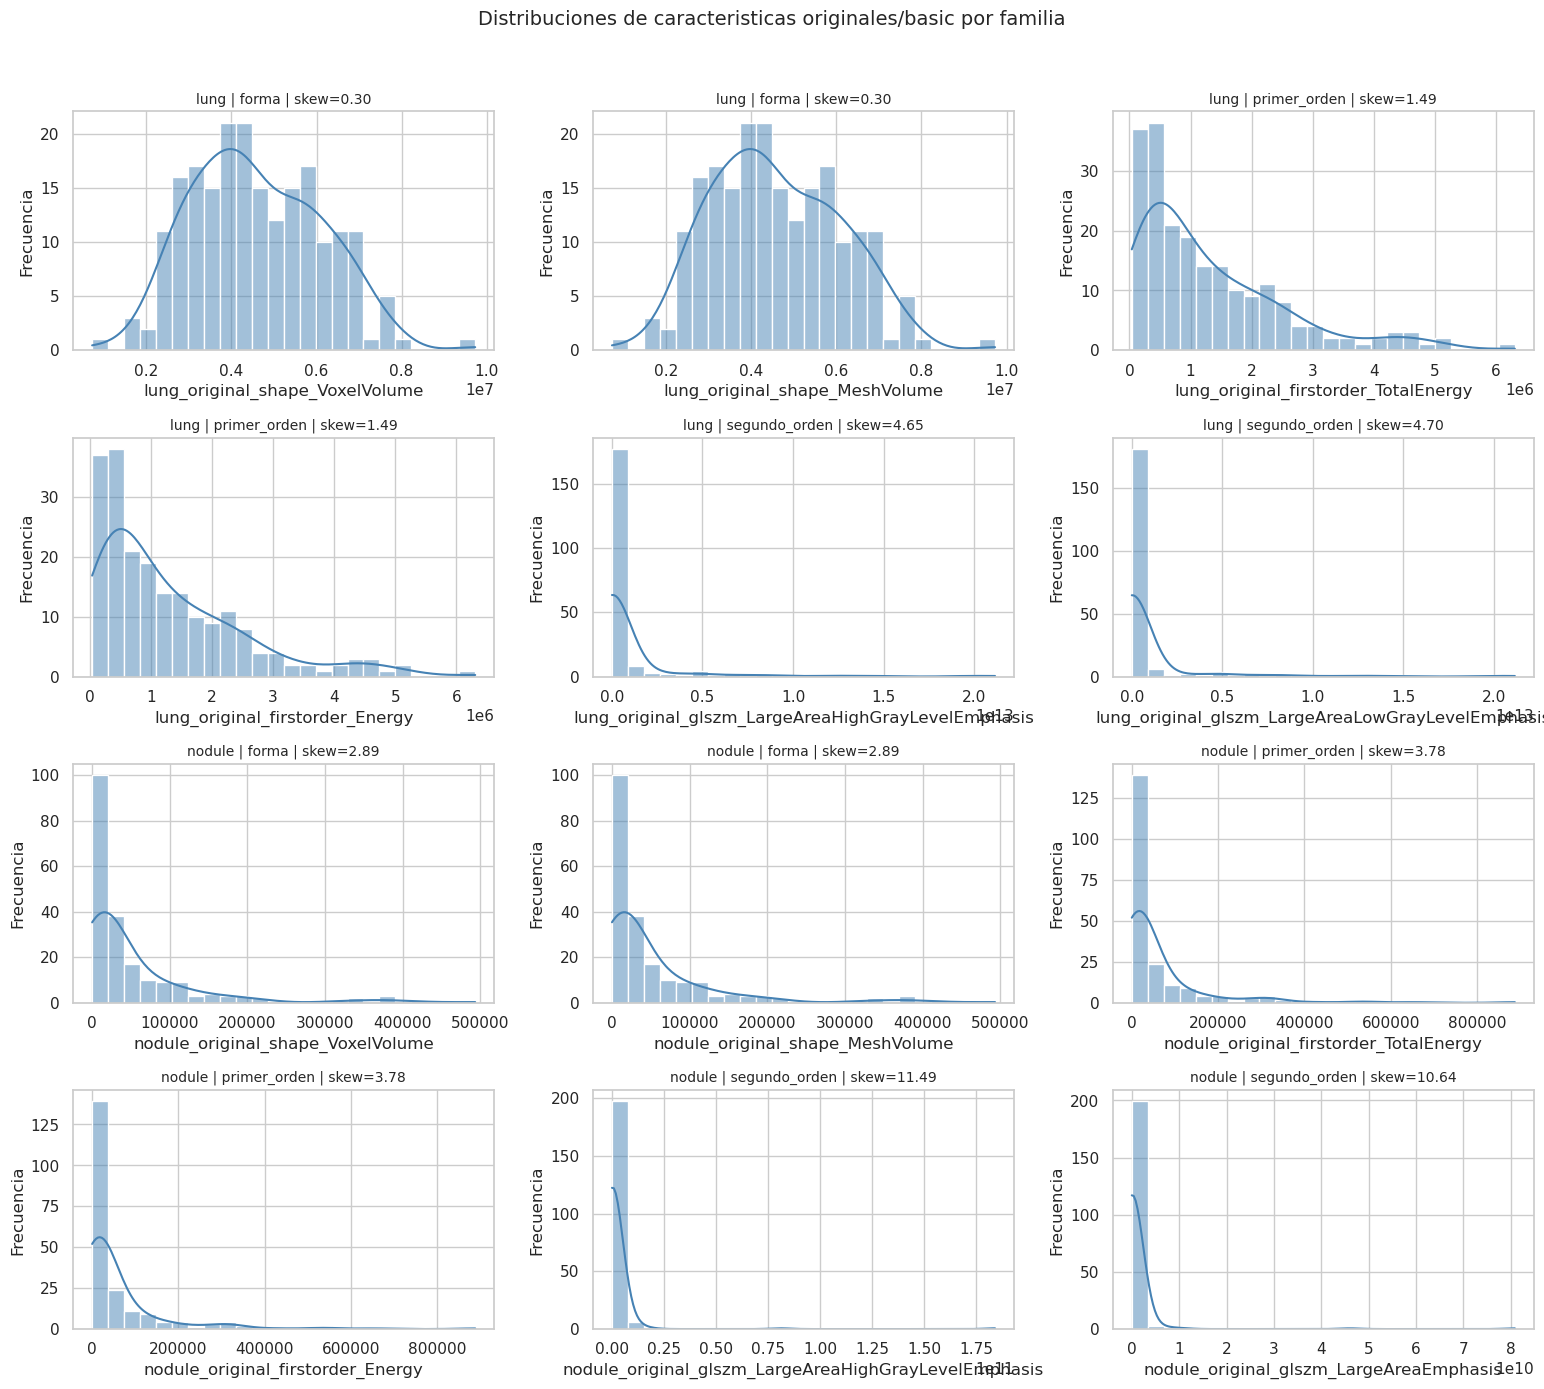

Original/basic: 99 redundantes eliminadas; quedan 115 de 214 features.
Mapa de correlacion: caracteristicas radiomicas originales/basic: mostrando 40 de 214 variables con mayor correlacion media absoluta.


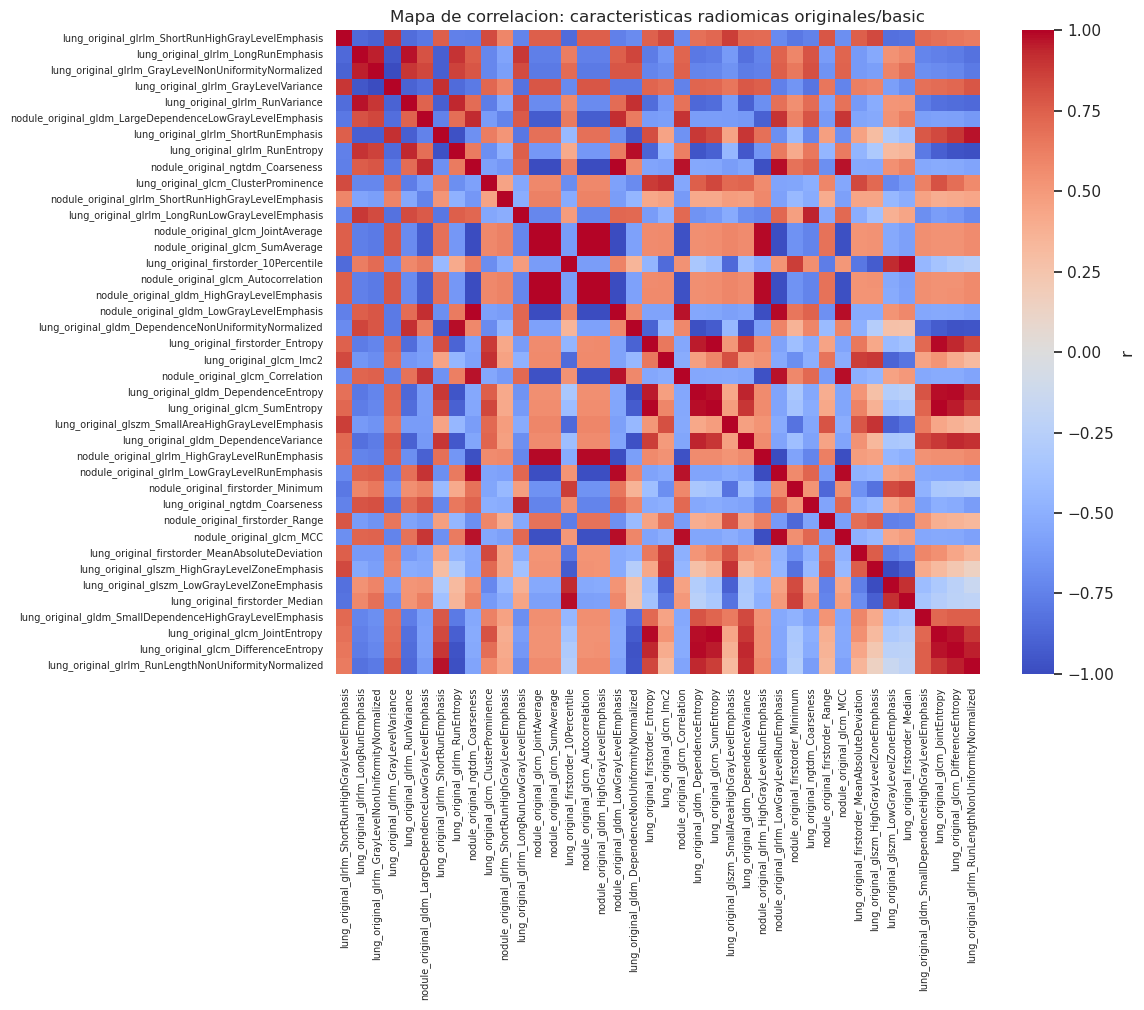

Mapa de correlacion: originales/basic sin redundantes: mostrando 40 de 115 variables con mayor correlacion media absoluta.


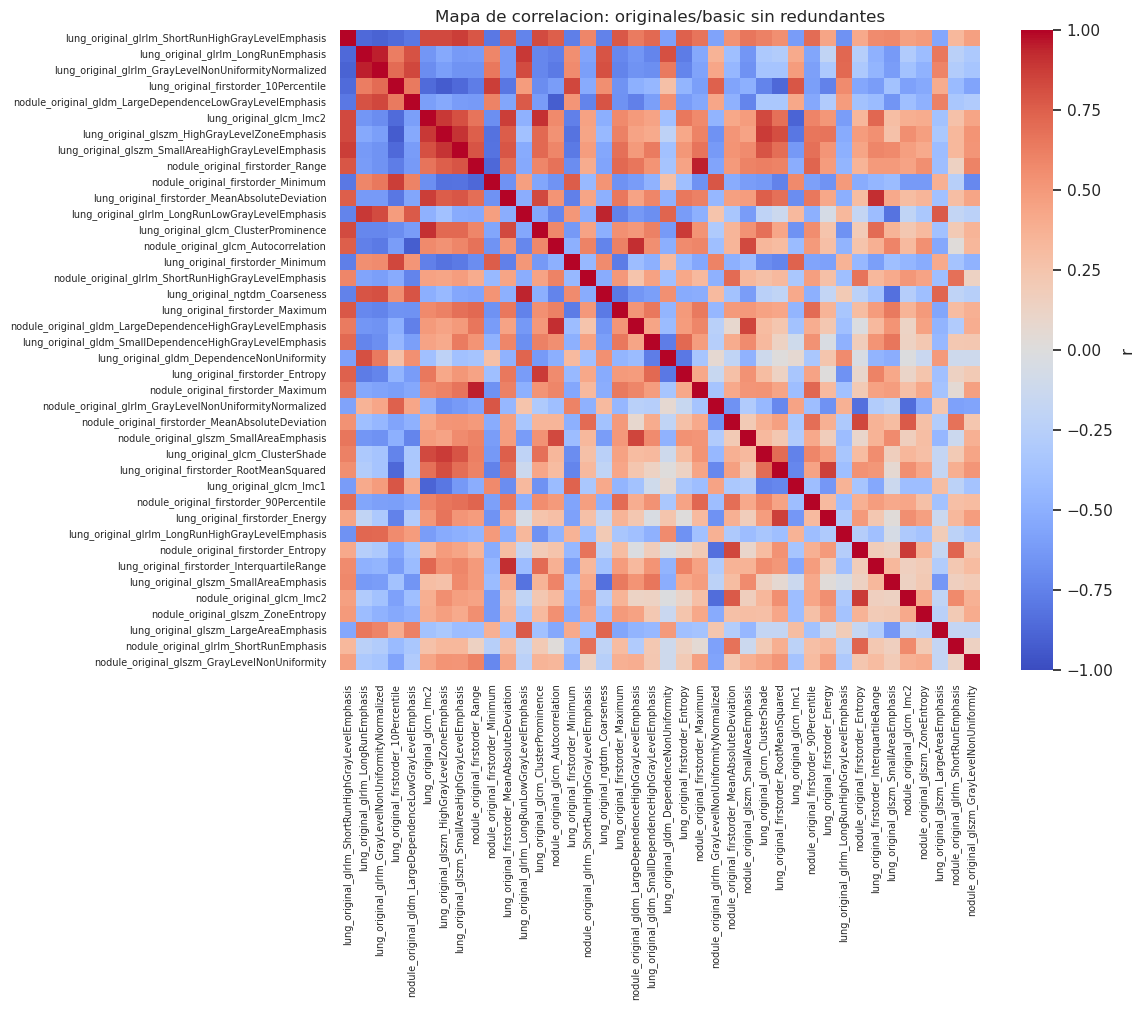

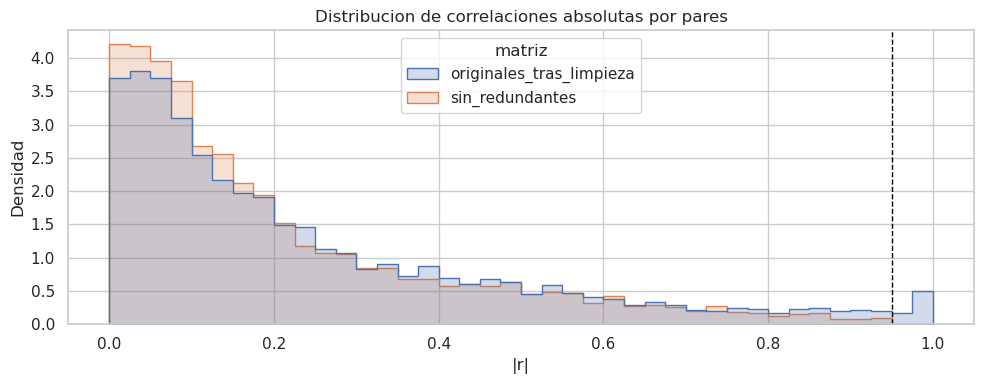

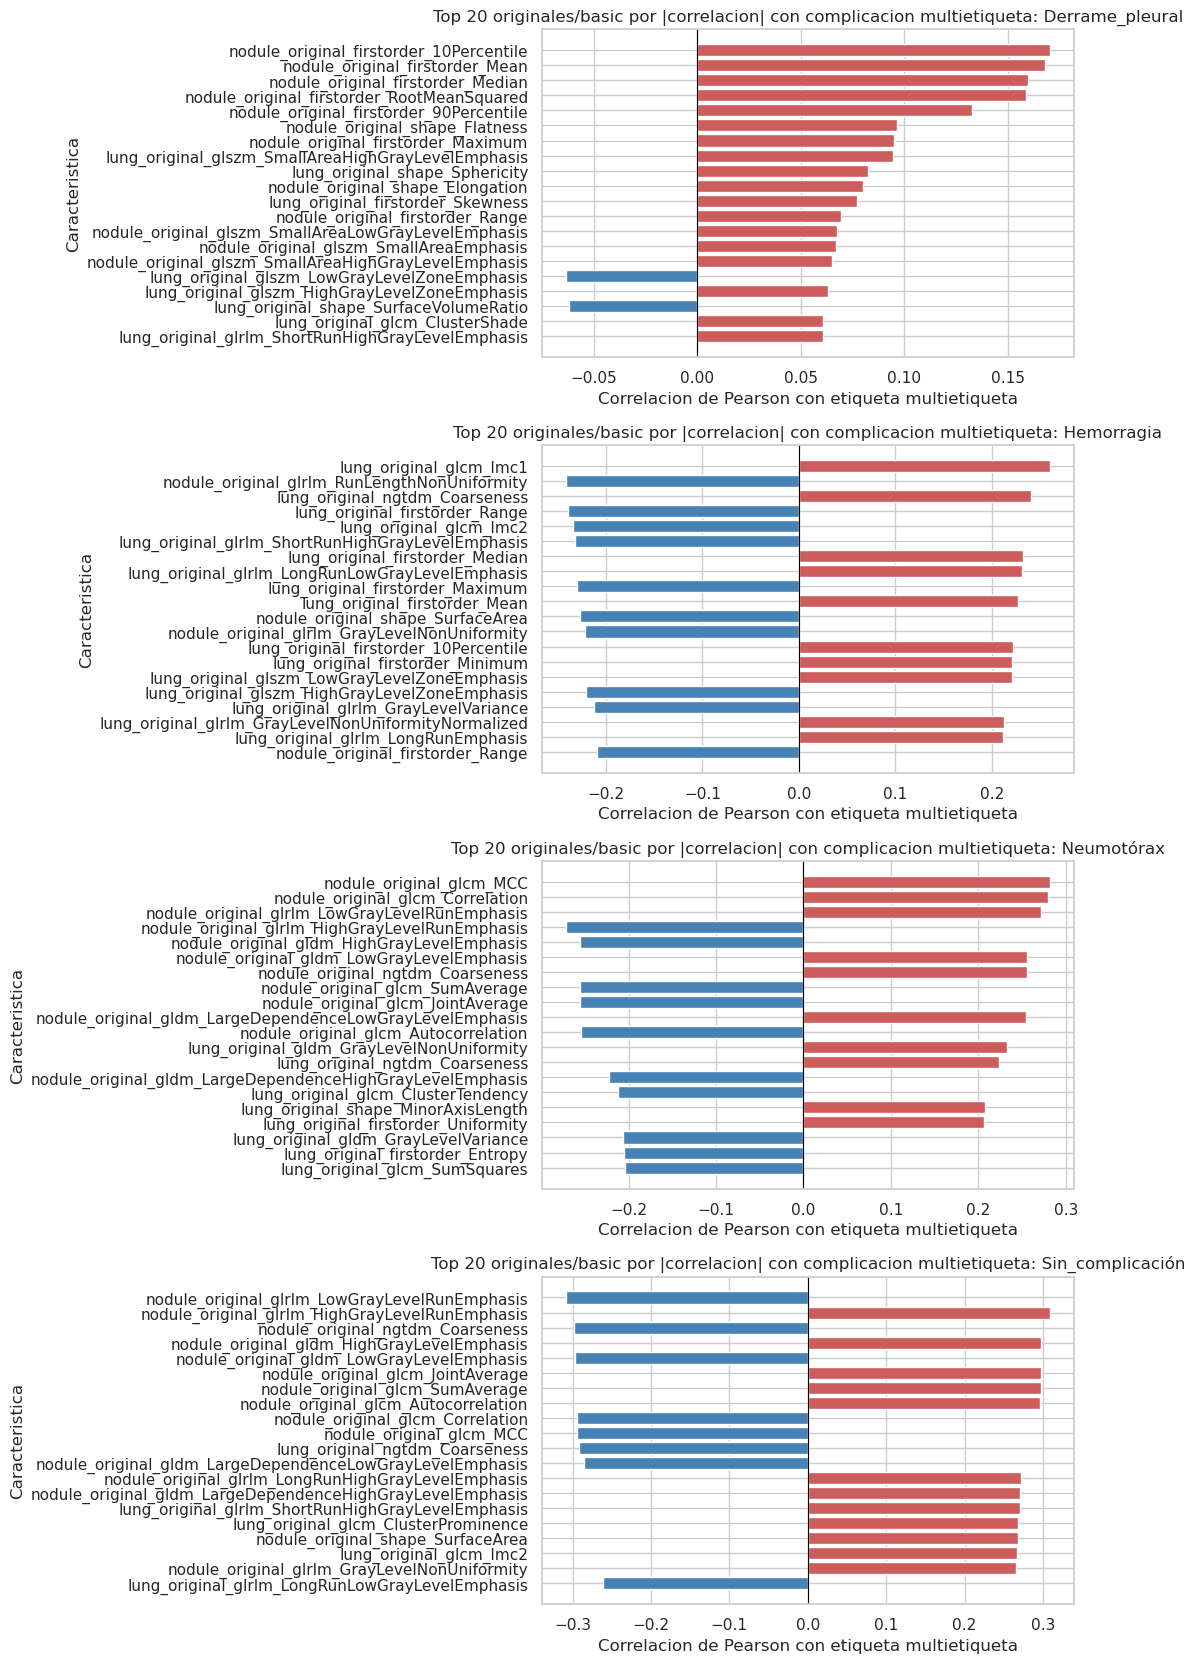

,target,feature,corr_con_etiqueta,abs_corr
0,Derrame_pleural,nodule_original_firstorder_10Percentile,0.170272,0.170272
1,Derrame_pleural,nodule_original_firstorder_Mean,0.168191,0.168191
2,Derrame_pleural,nodule_original_firstorder_Median,0.159736,0.159736
3,Derrame_pleural,nodule_original_firstorder_RootMeanSquared,0.158866,0.158866
4,Derrame_pleural,nodule_original_firstorder_90Percentile,0.132603,0.132603
5,Derrame_pleural,nodule_original_shape_Flatness,0.096442,0.096442
6,Derrame_pleural,nodule_original_firstorder_Maximum,0.095101,0.095101
7,Derrame_pleural,lung_original_glszm_SmallAreaHighGrayLevelEmph...,0.094591,0.094591
8,Derrame_pleural,lung_original_shape_Sphericity,0.082493,0.082493
9,Derrame_pleural,nodule_original_shape_Elongation,0.080276,0.080276


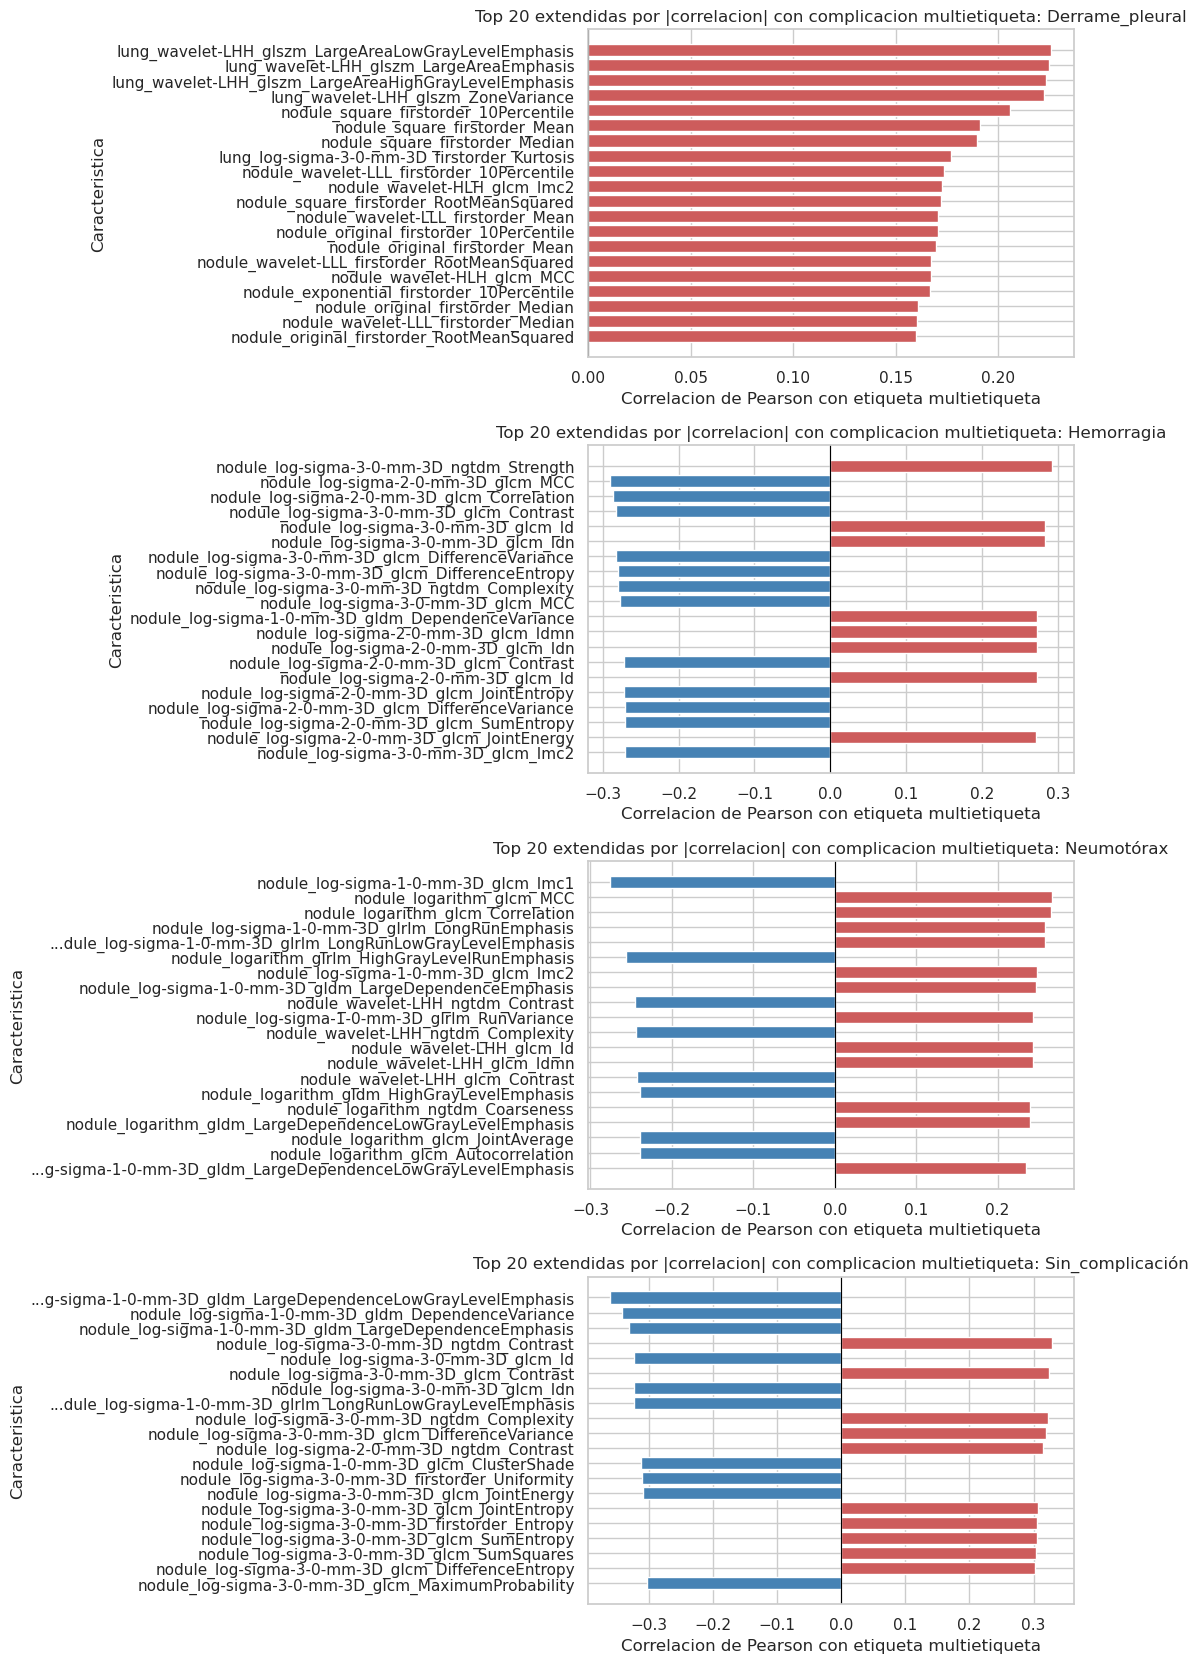

,target,feature,corr_con_etiqueta,abs_corr
0,Derrame_pleural,lung_wavelet-LHH_glszm_LargeAreaLowGrayLevelEm...,0.225634,0.225634
1,Derrame_pleural,lung_wavelet-LHH_glszm_LargeAreaEmphasis,0.224775,0.224775
2,Derrame_pleural,lung_wavelet-LHH_glszm_LargeAreaHighGrayLevelE...,0.223267,0.223267
3,Derrame_pleural,lung_wavelet-LHH_glszm_ZoneVariance,0.222477,0.222477
4,Derrame_pleural,nodule_square_firstorder_10Percentile,0.205601,0.205601
5,Derrame_pleural,nodule_square_firstorder_Mean,0.190890,0.190890
6,Derrame_pleural,nodule_square_firstorder_Median,0.189538,0.189538
7,Derrame_pleural,lung_log-sigma-3-0-mm-3D_firstorder_Kurtosis,0.177061,0.177061
8,Derrame_pleural,nodule_wavelet-LLL_firstorder_10Percentile,0.173693,0.173693
9,Derrame_pleural,nodule_wavelet-HLH_glcm_Imc2,0.172779,0.172779


In [ ]:
CLINICAL_LABEL_PATH = Path('/home/mcribilles/tfm/clinical_data/210pacientes/clinical_data_limpios.csv')
GRID_FEATURE_ROOT = Path('/home/mcribilles/tfm/codigo_nuevo/radiomica_grids/multimask_clinical_grid__2026-06-03__09-41-12/features')
BASIC_LUNG_NODULE_PATH = GRID_FEATURE_ROOT / 'radiomics__basic__lung__nodule.csv'
EXTENDED_LUNG_NODULE_PATH = GRID_FEATURE_ROOT / 'radiomics__extended__lung__nodule.csv'
MULTILABEL_TARGET_COLS = ['Derrame_pleural', 'Hemorragia', 'Neumotórax', 'Sin_complicación']
REDUNDANCY_CORR_THRESHOLD = globals().get('REDUNDANCY_CORR_THRESHOLD', 0.95)
CORR_HEATMAP_MAX_FEATURES = 40
HIST_FEATURES_PER_MASK_FAMILY = 2


if 'get_redundant_corr_cols' not in globals():
    def get_redundant_corr_cols(X: pd.DataFrame, threshold: float = REDUNDANCY_CORR_THRESHOLD) -> list[str]:
        if X.shape[1] < 2:
            return []
        corr = X.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        return [col for col in upper.columns if (upper[col] >= threshold).any()]


def first_file_by_extraction_type(files: list[Path], tipo_extraccion: str) -> Path | None:
    token = f'_{tipo_extraccion}_'
    matches = [p for p in files if token in p.stem]
    return sorted(matches)[0] if matches else None


def load_clean_feature_matrix(path: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    raw_df = load_dataset(path)
    prep_local = prepare_numeric_matrix(raw_df)
    X_local = prep_local['numeric_imputed'].copy()
    meta_local = raw_df[[c for c in BASE_META_COLS if c in raw_df.columns]].copy()
    return raw_df, X_local, meta_local


def feature_family(col: str) -> str:
    col_lower = col.lower()
    if '_shape_' in col_lower:
        return 'forma'
    if '_firstorder_' in col_lower:
        return 'primer_orden'
    if any(f'_{family}_' in col_lower for family in ['glcm', 'gldm', 'glrlm', 'glszm', 'ngtdm']):
        return 'segundo_orden'
    return 'otros'


def feature_mask(col: str) -> str:
    if col.startswith('trachea_bronchia_'):
        return 'trachea_bronchia'
    if col.startswith('lung_'):
        return 'lung'
    if col.startswith('nodule_'):
        return 'nodule'
    if col.startswith('vessels_'):
        return 'vessels'
    return 'otros'


def select_family_features(X: pd.DataFrame, family_name: str, mask_name: str | None = None, n: int = HIST_FEATURES_PER_MASK_FAMILY) -> list[str]:
    candidates = [c for c in X.columns if feature_family(c) == family_name]
    if mask_name is not None:
        candidates = [c for c in candidates if feature_mask(c) == mask_name]
    if not candidates:
        return []
    variances = X[candidates].var(numeric_only=True).sort_values(ascending=False)
    return variances.head(n).index.tolist()


def short_feature_name(col: str, max_len: int = 58) -> str:
    return col if len(col) <= max_len else '...' + col[-max_len:]


def plot_histogram_grid(X: pd.DataFrame, selected_cols: list[str], title: str) -> None:
    if not selected_cols:
        print(f'No hay columnas para histogramas: {title}')
        return
    n_cols = 3
    n_rows = int(np.ceil(len(selected_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.4 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, selected_cols):
        values = X[col].replace([np.inf, -np.inf], np.nan).dropna()
        skew_value = values.skew() if len(values) > 2 else np.nan
        sns.histplot(values, kde=True, bins=24, color='steelblue', ax=ax)
        ax.set_title(f'{feature_mask(col)} | {feature_family(col)} | skew={skew_value:.2f}', fontsize=10)
        ax.set_xlabel(short_feature_name(col))
        ax.set_ylabel('Frecuencia')
    for ax in axes[len(selected_cols):]:
        ax.axis('off')
    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


def select_heatmap_columns_by_correlation(X: pd.DataFrame, max_features: int = CORR_HEATMAP_MAX_FEATURES) -> list[str]:
    corr = X.corr().abs()
    if corr.shape[0] <= max_features:
        return corr.columns.tolist()
    mean_abs_corr = corr.where(~np.eye(corr.shape[0], dtype=bool)).mean().sort_values(ascending=False)
    return mean_abs_corr.head(max_features).index.tolist()


def plot_correlation_heatmap(X: pd.DataFrame, title: str, max_features: int = CORR_HEATMAP_MAX_FEATURES) -> None:
    if X.shape[1] < 2:
        print(f'No hay suficientes columnas para correlacion: {title}')
        return
    selected_cols = select_heatmap_columns_by_correlation(X, max_features=max_features)
    if len(selected_cols) < X.shape[1]:
        print(f'{title}: mostrando {len(selected_cols)} de {X.shape[1]} variables con mayor correlacion media absoluta.')
    corr = X[selected_cols].corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, cbar_kws={'label': 'r'})
    plt.title(title)
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.show()


def upper_abs_corr_values(X: pd.DataFrame) -> pd.Series:
    corr = X.corr().abs()
    upper_mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
    return corr.where(upper_mask).stack().rename('abs_corr')


def plot_pairwise_corr_distribution(X_before: pd.DataFrame, X_after: pd.DataFrame) -> None:
    before = upper_abs_corr_values(X_before).to_frame()
    before['matriz'] = 'originales_tras_limpieza'
    after = upper_abs_corr_values(X_after).to_frame()
    after['matriz'] = 'sin_redundantes'
    corr_dist = pd.concat([before, after], ignore_index=True)
    plt.figure(figsize=(10, 4))
    sns.histplot(data=corr_dist, x='abs_corr', hue='matriz', bins=40, stat='density', common_norm=False, element='step')
    plt.axvline(REDUNDANCY_CORR_THRESHOLD, color='black', linestyle='--', linewidth=1)
    plt.title('Distribucion de correlaciones absolutas por pares')
    plt.xlabel('|r|')
    plt.ylabel('Densidad')
    plt.tight_layout()
    plt.show()


def align_features_with_targets(X: pd.DataFrame, meta_df: pd.DataFrame, clinical_df: pd.DataFrame) -> pd.DataFrame:
    if 'patient_id' not in meta_df.columns:
        raise KeyError('No se puede cruzar con clinica porque falta patient_id en metadatos radiomics.')
    feature_df = pd.concat([meta_df[['patient_id']].reset_index(drop=True), X.reset_index(drop=True)], axis=1)
    return feature_df.merge(clinical_df[['patient_id'] + MULTILABEL_TARGET_COLS], on='patient_id', how='inner')


def plot_label_correlation_heatmap(clinical_df: pd.DataFrame) -> None:
    label_corr = clinical_df[MULTILABEL_TARGET_COLS].corr()
    plt.figure(figsize=(6, 5))
    sns.heatmap(label_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)
    plt.title('Correlacion entre etiquetas de complicacion')
    plt.tight_layout()
    plt.show()


def plot_top_multilabel_correlations(X: pd.DataFrame, meta_df: pd.DataFrame, clinical_df: pd.DataFrame, title: str, top_n: int = 20) -> pd.DataFrame:
    merged = align_features_with_targets(X, meta_df, clinical_df)
    if merged.empty:
        print(f'No hay pacientes cruzados para {title}.')
        return pd.DataFrame()
    feature_cols = [c for c in X.columns if c in merged.columns]
    top_tables = []
    fig, axes = plt.subplots(len(MULTILABEL_TARGET_COLS), 1, figsize=(11, 4.2 * len(MULTILABEL_TARGET_COLS)))
    axes = np.array(axes).reshape(-1)
    for ax, label_col in zip(axes, MULTILABEL_TARGET_COLS):
        y = merged[label_col]
        if y.nunique(dropna=True) < 2:
            ax.axis('off')
            ax.set_title(f'{label_col}: etiqueta constante en pacientes cruzados')
            continue
        corr = merged[feature_cols].corrwith(y).dropna().sort_values(key=lambda s: s.abs(), ascending=False)
        top_corr = corr.head(top_n).rename('corr_con_etiqueta').reset_index().rename(columns={'index': 'feature'})
        top_corr.insert(0, 'target', label_col)
        top_corr['abs_corr'] = top_corr['corr_con_etiqueta'].abs()
        top_tables.append(top_corr)
        plot_df = top_corr.iloc[::-1].copy()
        colors = np.where(plot_df['corr_con_etiqueta'] >= 0, 'indianred', 'steelblue')
        ax.barh(plot_df['feature'].map(short_feature_name), plot_df['corr_con_etiqueta'], color=colors)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'{title}: {label_col}')
        ax.set_xlabel('Correlacion de Pearson con etiqueta multietiqueta')
        ax.set_ylabel('Caracteristica')
    plt.tight_layout()
    plt.show()
    if not top_tables:
        return pd.DataFrame()
    top_corr_all = pd.concat(top_tables, ignore_index=True)
    display(top_corr_all)
    return top_corr_all


basic_path = BASIC_LUNG_NODULE_PATH if BASIC_LUNG_NODULE_PATH.exists() else first_file_by_extraction_type(all_files, 'basic')
extended_path = EXTENDED_LUNG_NODULE_PATH if EXTENDED_LUNG_NODULE_PATH.exists() else first_file_by_extraction_type(all_files, 'extended')
if basic_path is None:
    raise FileNotFoundError('No hay CSV basic utilizable para analizar caracteristicas originales.')
if extended_path is None:
    raise FileNotFoundError('No hay CSV extended utilizable para analizar caracteristicas extendidas.')

clinical_labels_df = pd.read_csv(CLINICAL_LABEL_PATH)
missing_target_cols = [c for c in MULTILABEL_TARGET_COLS if c not in clinical_labels_df.columns]
if missing_target_cols:
    raise KeyError(f'Faltan columnas multietiqueta en la clinica: {missing_target_cols}')
clinical_labels_df = clinical_labels_df[['patient_id'] + MULTILABEL_TARGET_COLS].drop_duplicates('patient_id')
clinical_labels_df[MULTILABEL_TARGET_COLS] = clinical_labels_df[MULTILABEL_TARGET_COLS].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

basic_raw_df, X_basic, meta_basic = load_clean_feature_matrix(basic_path)
extended_raw_df, X_extended, meta_extended = load_clean_feature_matrix(extended_path)

hist_cols = []
for mask_name in ['lung', 'nodule']:
    for family in ['forma', 'primer_orden', 'segundo_orden']:
        hist_cols.extend(select_family_features(X_basic, family, mask_name=mask_name, n=HIST_FEATURES_PER_MASK_FAMILY))

print('Dataset original/basic usado:', basic_path.name)
print('Dataset extended usado:', extended_path.name)
print('Mascaras en features originales/basic:', X_basic.columns.map(feature_mask).value_counts().to_dict())
print('Mascaras en features extendidas:', X_extended.columns.map(feature_mask).value_counts().to_dict())
print('Pacientes con etiquetas clinicas:', clinical_labels_df['patient_id'].nunique())
print('Etiquetas multietiqueta:', MULTILABEL_TARGET_COLS)
print('Features originales/basic tras limpieza:', X_basic.shape[1])
print('Features extendidas tras limpieza:', X_extended.shape[1])

display(clinical_labels_df[MULTILABEL_TARGET_COLS].sum().rename('n_positivos').to_frame())
plot_label_correlation_heatmap(clinical_labels_df)
plot_histogram_grid(X_basic, hist_cols, 'Distribuciones de caracteristicas originales/basic por familia')

redundant_original_cols = get_redundant_corr_cols(X_basic, threshold=REDUNDANCY_CORR_THRESHOLD)
X_basic_nonredundant = X_basic.drop(columns=redundant_original_cols, errors='ignore')
print(f'Original/basic: {len(redundant_original_cols)} redundantes eliminadas; quedan {X_basic_nonredundant.shape[1]} de {X_basic.shape[1]} features.')

plot_correlation_heatmap(X_basic, 'Mapa de correlacion: caracteristicas radiomicas originales/basic')
plot_correlation_heatmap(X_basic_nonredundant, 'Mapa de correlacion: originales/basic sin redundantes')
plot_pairwise_corr_distribution(X_basic, X_basic_nonredundant)

top20_original_multilabel = plot_top_multilabel_correlations(
    X_basic,
    meta_basic,
    clinical_labels_df,
    'Top 20 originales/basic por |correlacion| con complicacion multietiqueta',
)
top20_extended_multilabel = plot_top_multilabel_correlations(
    X_extended,
    meta_extended,
    clinical_labels_df,
    'Top 20 extendidas por |correlacion| con complicacion multietiqueta',
)

## 10. Conclusiones del EDA

Este notebook localiza 10 CSV utilizables: 8 procedentes del batch multiwindowing (`resize_cube128_multiwindowing_separadas` y `resize_cube64_multiwindowing_separadas`, cada uno con `basic`/`extended` y `all_raw`/`all_per_mask`) y 2 CSV de referencia `lung+nodule`. Las dos configuraciones multiwindowing contienen 205 pacientes. En formato `all_raw` aparece una fila por paciente, mientras que en `all_per_mask` aparecen varias filas por paciente, una por máscara disponible.

En las características multiwindowing, la dimensionalidad aumenta de forma clara. Las matrices `basic` tienen 1284 características candidatas, derivadas de 4 máscaras, 3 canales de ventana y las familias radiomics originales. Las matrices `extended` alcanzan 23604 características candidatas por CSV, por la combinación de canales, máscaras e image types extendidos. Esta dimensionalidad es demasiado alta para usarla directamente sin filtrado, especialmente teniendo solo alrededor de 205 pacientes.

La redundancia entre variables es alta. En el dataset seleccionado (`resize_cube128_multiwindowing_separadas_basic_all_per_mask`) quedan 1284 características tras limpieza, pero 841 son redundantes usando correlación absoluta >= 0.95. En conjunto, los CSV `basic` pasan de 214-1284 características a 115-499 características no redundantes. En `extended`, la redundancia completa solo se calcula para el CSV de referencia `lung+nodule` porque los multiwindowing extendidos superan el umbral de seguridad de 5000 variables; aun así, el rango de 2961 a 23604 features confirma que será necesario aplicar selección de variables antes de modelar.

La estimación de reducción dimensional en los CSV `lung+nodule` también apunta en la misma dirección: las características originales/basic pasan de 214 a 115 al eliminar redundantes, y a 26 componentes para explicar el 95% de la varianza con PCA. Las extendidas pasan de 2961 a 1325 sin redundantes, y a 57 componentes para PCA95. Esto sugiere que la mayor parte de la información está concentrada en un subespacio mucho menor que el número bruto de variables.

Respecto al objetivo clínico, el problema es tratado como multietiqueta. La distribución está desbalanceada: `Derrame_pleural` tiene solo 1 positivo, `Hemorragia` 49, `Neumotórax` 64 y `Sin_complicación` 105. Por tanto, las asociaciones de `Derrame_pleural` no son interpretables de forma robusta y no deberían usarse para sacar conclusiones.

Las correlaciones feature-etiqueta son moderadas, no extremadamente altas. En basic, las máximas correlaciones absolutas aproximadas son 0.17 para `Derrame_pleural`, 0.26 para `Hemorragia`, 0.28 para `Neumotórax` y 0.31 para `Sin_complicación`. En extended suben ligeramente, con máximos aproximados de 0.23, 0.29, 0.28 y 0.36 respectivamente. Esto indica que puede haber señal radiomics, especialmente en texturas de nódulo y pulmón, pero probablemente distribuida entre muchas variables y no dominada por una sola característica.
